# News Analysis - Intelligence Pipeline

End-to-end pipeline for the daily analysis of Italian news.
Starting from RSS feeds, it produces four main outputs used in the final report:

1. **Daily wordcloud** of the most important concepts (colored by structural role)
2. **Top 10 concepts** (top-5 *core* + top-5 *bridge*) with an LLM-generated explanation
3. **Top 10 articles** with key concepts highlighted inline
4. **Main themes** (Louvain communities) with an LLM-generated title, graph/wordcloud, and representative articles

## Pipeline stages

1. RSS ingestion
2. Semantic clustering (UMAP + HDBSCAN)
3. Keyword and entity extraction (custom KeyBERT with MMR)
4. Co-occurrence graph construction
5. Graph metric computation
6. Fuzzy classification of node roles
7. Ranking
8. Rendering and narration through an LLM

## Output order

After the full computation pipeline runs, the report is rendered in the following order:

1. **Daily wordcloud** of the most important concepts
2. **Daily recap** summarising the last 24 hours from a thematically diverse selection of articles
3. **Top 10 articles** with key concepts highlighted inline
4. **Top-5 core + top-5 bridge concepts** with ego-graph analysis and LLM-generated descriptions
5. **Main themes** (Louvain communities) with title, visualisation and representative articles
6. **Cross-source coverage and lexical framing** for the top-5 clusters

## 1. Imports

All imports are consolidated here and grouped by domain.
Pipeline logic lives in the `scripts/` package; this notebook only orchestrates.

In [1]:
import sys
sys.path.append('..')

# Standard library
import logging
from datetime import datetime

# Data
import numpy as np
import pandas as pd

# Graphs
import networkx as nx

# Notebook rendering
from IPython.display import HTML, Markdown, display

# NLP and stopwords
from nltk.corpus import stopwords

# Embeddings, dimensionality reduction, clustering
from umap import UMAP
from sklearn.cluster import HDBSCAN

# TF-IDF for cluster representation
from sklearn.feature_extraction.text import TfidfVectorizer

# Pipeline configuration and constants
from scripts.config import (
    ALPHA,
    CORR_THRESHOLD,
    CSV_FILE,
    CUMULATIVE_THRESHOLD,
    KEYWORD_MAX_WORDS,
    MIN_ARTICLES,
    MIN_SCORES,
    MIN_SOURCES,
    MISTRAL_API_KEY,
    MISTRAL_MODEL,
    N_RUNS,
    TOP_N,
)
# Note: MAIN_SECTION_NAME and BLOCKLIST are also defined in config.py and
# consumed by ingestion / lemmatization respectively; they are not used
# directly here and therefore not imported.

# NLP models
from scripts.models import device, embedding_model, nlp_it, stop_words_italian

# Pipeline modules
from scripts.ingestion import build_news_dataframe, read_feeds_csv
from scripts.preprocessing import (
    classify_keyword_type,
    clean_pipe_edges,
    merge_entity_lists,
    preprocess_text,
)
from scripts.keyword_extraction import extract_keywords_corpus_with_types
from scripts.lemmatization import LemmaResolver, aggregate_tags_and_entities
from scripts.graph_builder import cooccurrence_matrix_pipe, graph_from_cooc
from scripts.graph_metrics import compute_node_metrics, normalize_metrics
from scripts.fuzzy_classifier import classify_nodes
from scripts.ranking import (
    build_ego_profiles,
    compute_combined_score,
    compute_relevance_score,
    select_top_nodes,
)
from scripts.communities import (
    rank_communities,
    run_louvain_best_partition,
)
from scripts.cluster_ranking import (
    compute_cluster_composite_score,
    compute_cluster_metrics,
    extract_framing_per_cluster,
    map_clusters_to_concepts,
    select_eligible_top_clusters,
)
from scripts.llm_narration import (
    analyse_top_communities,
    analyse_top_words,
    summarise_cluster,
    summarise_day_recap,
)
from scripts.recap import select_articles_for_recap

# Visualisation modules
from scripts.viz_palette import ROLE_COLORS, ROLE_HIGHLIGHT_COLORS, set_palette
from scripts.viz_news_render import render_news_html, score_news_importance
from scripts.viz_ego_graph import plot_ego_graph
from scripts.viz_communities import plot_community
from scripts.viz_wordcloud import plot_daily_wordcloud
from scripts.viz_framing import describe_cat_column_stacked, display_framing_table

# Merging of similar news, for last section
from scripts.cluster_merge import merge_similar_clusters

2026-05-26 10:49:06,524 INFO Use pytorch device_name: cuda:0
2026-05-26 10:49:06,526 INFO Load pretrained SentenceTransformer: sentence-transformers/paraphrase-multilingual-mpnet-base-v2


## 2. Configuration

Project-level constants are defined in `scripts/config.py` and have already been imported in section 1. Deployment-dependent values (paths, API keys, fonts) live in the `.env` file at the project root; analytical parameters (`TOP_N`, `ALPHA`, `CUMULATIVE_THRESHOLD`, `MIN_SCORES`, `BLOCKLIST`, ...) are Python attributes in `config.py`. Edit those files, not the notebook.

In [2]:
# Quick environment check
print(f"Device:        {device}")
print(f"CSV file:      {CSV_FILE}")
print(f"Mistral model: {MISTRAL_MODEL}")

Device:        cuda
CSV file:      C:\Users\wolfl\Python Projects\News\Analisi_News\sources\news_feeds.csv
Mistral model: mistral-large-latest


## 3. NLP models

Loaded only once at startup and reused throughout the pipeline:

- **spaCy `it_core_news_lg`** for Italian NER and lemmatization
- **`paraphrase-multilingual-mpnet-base-v2`** for semantic embeddings (multilingual sentence transformer)
- **NLTK** stopwords and tokenizer for Italian

All three are imported from `scripts.models`. The first import in section 1 already triggered loading; no additional setup is needed here.

## 4. RSS ingestion

Feed reading and article assembly. Implementation in `scripts/ingestion.py`.

### 4.1 Running the ingestion

In [3]:
feeds = read_feeds_csv(CSV_FILE)
if not feeds:
    raise SystemExit(f"No feeds found in {CSV_FILE}. Expected header: source,section,url")

df = build_news_dataframe(feeds)
logging.info("Articles collected (deduplicated): %d", len(df))

2026-05-26 10:49:14,371 INFO Fetching feed: Prima Pagina         https://www.ansa.it/sito/ansait_rss.xml
C:\Users\wolfl\Python Projects\News\Analisi_News\notebooks\..\scripts\ingestion.py:90: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  "description": normalise_feed_whitespace(BeautifulSoup(
2026-05-26 10:49:14,526 INFO Fetching feed: Politica             https://www.ansa.it/sito/notizie/politica/politica_rss.xml
2026-05-26 10:49:14,687 INFO Fetching feed: News estere          https://www.ansa.it/sito/notizie/mondo/mondo_rss.xml
2026-05-26 10:49:14,865 INFO Fetching feed: News Europa          https://www.ansa.it/europa/notizie/rss.xml
2026-05-26 10:49:15,001 INFO Fetching feed: Europarlamento       https://www.ansa.it/europa/notizie/europarlamento/news/europarlamento_rss.xml
2026-05-26 10:49:15,162 INFO Fetching feed: Sport                https://www.ansa.it/sito/notizie/sp

### 4.2 Snapshot and working dataset

I export a daily Excel snapshot for reproducibility. The working dataset (`data`) is restricted to the last two days: this is the time window used by clustering, keyword extraction, and graph construction.

In [4]:
# Snapshot for reproducibility
# Un-comment to log the news extraction
#df.to_excel(f'estrazione_{datetime.now().strftime("%Y%m%d")}.xlsx', index=False)
# df = pd.read_excel('estrazione_20260325.xlsx')

df['date'] = pd.to_datetime(df['date'])
df['text'] = df['title'].fillna('') + '\n' + df['description'].fillna('')

In [5]:
# Restrict to the last 2 available dates
data = df[['source', 'section', 'date', 'time', 'text']].copy()
last_days = list(np.sort(data['date'].unique())[-2:])
data = data[data['date'].apply(lambda d: d in last_days)].reset_index(drop=True)

print(f"Working dataset: {data.shape[0]} articles across {data['date'].nunique()} days")
data.info()

Working dataset: 1191 articles across 2 days
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1191 entries, 0 to 1190
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   source   1191 non-null   object        
 1   section  1191 non-null   object        
 2   date     1191 non-null   datetime64[ns]
 3   time     1191 non-null   object        
 4   text     1191 non-null   object        
dtypes: datetime64[ns](1), object(4)
memory usage: 46.7+ KB


In [6]:
# Getting distinct journals names
distinct_journals = data['source'].unique().tolist()

In [7]:
# Per-source colour map for stacked-bar visualisations downstream.
# The palette factory lives in viz_palette.set_palette.
journal_color_map = {
    journal: color
    for journal, color in zip(distinct_journals, set_palette(len(distinct_journals)))
}

## 5. Text preprocessing

Italian tokenization, stopword removal, and truncation to the first `KEYWORD_MAX_WORDS` tokens. Truncation is justified by the fact that the informative content of a news item is concentrated in the lead.

In [8]:
data['clean text'] = data['text'].apply(
    lambda t: ' '.join(preprocess_text(
        ' '.join(str(t).split()[:KEYWORD_MAX_WORDS])
    ))
)

## 6. Semantic clustering (UMAP + HDBSCAN)

Articles are embedded with a multilingual sentence transformer, projected to 5 dimensions through UMAP (cosine metric, `min_dist=0` to favor compact clusters), and clustered with HDBSCAN using `cluster_selection_method='eom'`.

Articles assigned to cluster `-1` are treated as noise (no thematic group).

In [9]:
emb = embedding_model.encode(data['text'].tolist(), show_progress_bar=True)

umap_emb = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=0,
).fit_transform(emb)

hdbscan_model = HDBSCAN(
    min_cluster_size=2,
    metric='euclidean',
    cluster_selection_method='eom',
)
labels = hdbscan_model.fit_predict(umap_emb)

data['Topic'] = labels

print(f"Clusters found: {data['Topic'].nunique() - 1}  (excluding noise)")
print(data['Topic'].value_counts().head(10))

Batches:   0%|          | 0/38 [00:00<?, ?it/s]

C:\Users\wolfl\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Clusters found: 293  (excluding noise)
Topic
-1      192
 4       29
 132     16
 9       11
 36      11
 33      10
 236      9
 121      9
 192      8
 248      8
Name: count, dtype: int64


C:\Users\wolfl\anaconda3\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


## 7. NER classification helper

The helper `classify_keyword_type` decides whether a token is a named entity or a generic concept. Implementation in `scripts/preprocessing.py`.

## 8. Keyword extraction - custom KeyBERT with MMR

A custom KeyBERT pipeline with MMR (Maximal Marginal Relevance) extracts keywords and entities from articles. Implementation in `scripts/keyword_extraction.py`.

## 9. Cluster representation (TF-IDF + NER)

Each HDBSCAN cluster is summarized by its top TF-IDF terms (lower IDF = more cluster-specific term). These terms are then split into named entities and generic tags through the NER helper, mirroring the structure of the KeyBERT outputs from section 8.

In [10]:
# Initialize with the noise-cluster placeholder
topics_dict = {
    'Topic':    [-1],
    'Name':     ['Misc'],
    'Entities': ['Misc'],
}

for label in sorted(set(labels)):
    if label == -1:
        continue

    docs     = data[data['Topic'] == label]['clean text'].tolist()
    docs_raw = data[data['Topic'] == label]['text'].tolist()
    if not docs:
        continue

    # TF-IDF: lower IDF score = more specific to this cluster.
    # Fit on already lowercased documents so all extracted terms are lowercase.
    docs_lower = [d.lower() for d in docs]
    vec        = TfidfVectorizer().fit(docs_lower)
    terms      = vec.get_feature_names_out()
    top_terms  = terms[vec.idf_.argsort()][:5].tolist()  # already lowercase from the fit

    # Parse the concatenated raw text only once for NER
    cluster_text = ' '.join(docs)
    doc_spacy    = nlp_it(cluster_text)

    entity_terms  = []
    generic_terms = []
    for term in top_terms:
        is_entity, _ = classify_keyword_type(term, doc_spacy, nlp_it)
        if is_entity:
            entity_terms.append(term)
        else:
            generic_terms.append(term)

    topics_dict['Topic'].append(label)
    topics_dict['Name'].append('|'.join(generic_terms) if generic_terms else '')
    topics_dict['Entities'].append('|'.join(entity_terms) if entity_terms else '')

data = data.merge(pd.DataFrame(topics_dict))
print('Cluster keyword extraction complete.')
data.head()

Cluster keyword extraction complete.


,source,section,date,time,text,clean text,Topic,Name,Entities
0,Il Fatto Quotidiano,Home,2026-05-26,10:46:59,“Siamo i Me contro te col mutuo. Ci hanno offe...,me te mutuo offerto grande fratello rifiutato ...,148,abis|birra|cantante|casa|coppia,
1,Il Fatto Quotidiano,Home,2026-05-26,10:45:35,“Nicola Pietrangeli? Dico sempre che mi ha rov...,nicola pietrangeli dico sempre rovinato vita d...,190,così|colò,antonino|licia|pietrangeli
2,Adnkronos,Prima Pagina,2026-05-26,10:45:21,Un anno fa il femminicidio della 14enne Martin...,anno fa femminicidio martina carbonaro madre s...,-1,Misc,Misc
3,Ansa,Economia,2026-05-26,10:44:37,"Coldiretti Vercelli-Biella, prezzi riso in cad...",coldiretti prezzi riso caduta libera costi ste...,-1,Misc,Misc
4,Ansa,Prima Pagina,2026-05-26,10:43:43,Istat: flussi turistici in aumento nel primo t...,istat flussi turistici aumento primo trimestre...,197,arrivi|aumento|componente|far|flussi,


## 10. KeyBERT extraction on clusters

I apply the custom KeyBERT pipeline (section 8) to the concatenated clean text of each cluster. The output is merged into the working dataset next to the TF-IDF representation from section 9.

In [11]:
news_groups = {'Topic': [], 'News': []}
for label in sorted(set(labels)):
    if label >= 0:
        docs = data[data['Topic'] == label]['clean text'].tolist()
        news_groups['Topic'].append(label)
        news_groups['News'].append('\n\n'.join(docs))

keywords_per_cluster = extract_keywords_corpus_with_types(
    docs=news_groups['News'],
    model=embedding_model,
    ngram_range=(1, 2),
    top_n=5,
    stop_words=stopwords.words('italian'),
    use_mmr=True,
    diversity=0.7,
    nlp=nlp_it,
)

# Keywords have already been lowercased by extract_keywords_single_doc
news_groups['Keywords'] = [
    '|'.join(kl['keyword'] for kl in doc['other_keywords'])
    for doc in keywords_per_cluster
]
news_groups['Entities2'] = [
    '|'.join(el['keyword'] for el in doc['entities'])
    for doc in keywords_per_cluster
]

data = data.merge(pd.DataFrame(news_groups)[['Topic', 'Keywords', 'Entities2']])
print('KeyBERT extraction on clusters complete.')

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

KeyBERT extraction on clusters complete.


## 11. Building the themes DataFrame

I consolidate cluster-level entities and tags from sections 9 and 10 into a single `themes_df` with columns `Topic, Tags, Entities, News`.

In [12]:
themes_df = pd.DataFrame(topics_dict).merge(pd.DataFrame(news_groups))
themes_df.drop(themes_df[themes_df['Topic'] == -1].index, inplace=True)
themes_df.columns = ['Topic', 'Keys', 'Entities', 'News', 'Keys2', 'Entities2']

themes_df['Entities'] = themes_df.apply(
    lambda row: merge_entity_lists(row['Entities'], row['Entities2']), axis=1
)
themes_df['Entities'] = themes_df['Entities'].apply(clean_pipe_edges)
themes_df.drop('Entities2', axis=1, inplace=True)

themes_df['Tags'] = (themes_df['Keys'] + '|' + themes_df['Keys2']).apply(
    lambda s: '|'.join(set(s.replace('|', ' ').split()))
)

themes_df = themes_df[['Topic', 'Tags', 'Entities', 'News']].copy()
themes_df['Tags'] = themes_df['Tags'].apply(clean_pipe_edges)

print(f"Themes: {themes_df.shape[0]} clusters")
themes_df.head()

Themes: 293 clusters


,Topic,Tags,Entities,News
0,0,bop|morto|rollins|sonny|anni|concerto|sassofon...,sonny rollins,morto sassofonista sonny rollins gigante jazz ...
1,1,nasceva|dentista|davis|anni|compositore|jazz|t...,davis|miles davis,miles davis nasceva anni fa padre dentista lot...
2,2,agi|morto|rollins|sonny|anni|sassofonista|jazz,sonny rollins,morto sonny rollins colosso sax mostro sacro j...
3,3,agi|città|soprattutto|caldo|allerta|arancioni|...,,allerta caldo italia bollini arancioni città a...
4,4,enciclica|volta|humanitas|papa|storia|artifici...,papa|leone|humanitas,papa ia papa ia vignetta fatto quotidiano edic...


## 12. KeyBERT extraction on individual documents

I run KeyBERT on each individual article (in addition to cluster-level extraction). This produces a more granular list of keywords and entities per article, complementary to the cluster-level signal.

In [13]:
keywords_per_single_news = extract_keywords_corpus_with_types(
    docs=data['clean text'].tolist(),
    model=embedding_model,
    ngram_range=(1, 2),
    top_n=5,
    stop_words=stopwords.words('italian'),
    use_mmr=True,
    diversity=0.7,
    nlp=nlp_it,
)

data = data[data.columns[:7]].copy()

# Keywords are already lowercase thanks to extract_keywords_single_doc
data['Keywords'] = [
    '|'.join(kl['keyword'] for kl in doc['other_keywords'])
    for doc in keywords_per_single_news
]
data['Entities'] = [
    '|'.join(el['keyword'] for el in doc['entities'])
    for doc in keywords_per_single_news
]

data['Keywords'] = data['Keywords'].apply(lambda s: '|'.join(set(s.replace('|', ' ').split())))
data['Entities'] = data['Entities'].apply(lambda s: '|'.join(set(s.replace('|', ' ').split())))

print('Single-document KeyBERT extraction complete.')

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Single-document KeyBERT extraction complete.


## 13. Aggregation of tags and entities

I aggregate cluster-level and document-level signals into two global corpus sets: `tags_list` (generic concepts) and `entities_list` (named entities). Mutual exclusivity is enforced multiple times: each transformation (merge, lowercase, POS filtering) may reintroduce overlap.

POS filter: tags keep `{NOUN, PROPN, ADJ, VERB}`, while entities keep `{PROPN, NOUN}`. VERBs are included among tags because, in Italian headlines, verbs can be semantically dense (e.g. `arrestare`, `vincere`, `dimettere`).

Implementation in `scripts/lemmatization.aggregate_tags_and_entities`.

In [14]:
tags_list, entities_list = aggregate_tags_and_entities(themes_df, data)

print(f"Unique generic tags   (post-POS filter): {len(tags_list)}")
print(f"Unique named entities (post-POS filter): {len(entities_list)}")

Promoted 118 tokens from tags to entities because they parse as PROPN in isolation
Unique generic tags   (post-POS filter): 3626
Unique named entities (post-POS filter): 457


## 14. Lemmatization

Asymmetric lemmatization: only **generic tags** are lemmatized, while **named entities** remain in their original form to preserve their identity (e.g. *Meloni* must not become *melone*).

`LemmaResolver` encapsulates the lemma maps and the co-occurrence normaliser. It is built once per daily corpus and exposes:

- `tags_set`, `entities_set`: the corpus-wide token sets after aggregation
- `raw_lemmas`: generic surface form -> canonical lemma
- `lemma_to_forms`: canonical lemma -> set of surface forms (entities map to themselves)
- `important_keywords_set`: tags U entities (original surface forms), used to filter co-occurrence inputs
  *before* lemma replacement
- `apply_lemmas_to_cooc_string(s)`: normaliser used by the co-occurrence builders in section 15

In [15]:
resolver = LemmaResolver(tags_list, entities_list)

# Convenience aliases used by the rest of the notebook.
tags_set               = resolver.tags_set
entities_set           = resolver.entities_set
raw_lemmas             = resolver.raw_lemmas
lemma_to_forms         = resolver.lemma_to_forms
important_keywords_set = resolver.important_keywords_set

print(f"Lemma map built for {len(raw_lemmas)} generic tags.")

Lemma map built for 3626 generic tags.


### 14.1 Inverse mapping: lemma to surface forms

Already built inside `LemmaResolver` (`lemma_to_forms`). For news rendering and ego-graph lookup, the inverse mapping is what we need: given the canonical lemma, the set of surface forms that map to it. Entities map to themselves (they were not lemmatized).

## 15. Building co-occurrence inputs

Two co-occurrence signals are built: cluster-level (each HDBSCAN cluster -> one co-occurrence string) and document-level (each article -> one co-occurrence string). Both are passed through `resolver.apply_lemmas_to_cooc_string` so that tags are normalised to their canonical lemmas and entities are preserved verbatim.

### 15.1 Signal 1 - cluster-level co-occurrence

In [16]:
themes_df['Tags'] = themes_df.apply(
    lambda row: merge_entity_lists(row['Entities'], row['Tags']), axis=1
)
themes_df['Tags'] = themes_df['Tags'].apply(clean_pipe_edges)
themes_df['Tags'] = themes_df['Tags'].apply(lambda s: '|'.join(set(s.split('|'))))
themes_df['Tags'] = themes_df['Tags'].apply(clean_pipe_edges)

similarity_by_topic_list = [
    resolver.apply_lemmas_to_cooc_string(
        '|'.join(t for t in s.split('|') if t in important_keywords_set)
    )
    for s in themes_df['Tags'].tolist()
]

### 15.2 Signal 2 - document-level co-occurrence

In [17]:
# Remove noise tokens from the clean text before building co-occurrences
data['clean text'] = (
    data['clean text']
    .str.replace('adnkronos', '', regex=False)
    .str.replace('  ', ' ', regex=False)
    .str.strip()
)

data['co_occurrences'] = data['clean text'].apply(lambda s: '|'.join(set(s.split())))

similarity_by_same_news = [
    resolver.apply_lemmas_to_cooc_string(
        '|'.join(k for k in s.split('|') if k in important_keywords_set)
    )
    for s in data['co_occurrences'].tolist()
]

print(f"Cluster-level co-occurrence strings:  {len(similarity_by_topic_list)}")
print(f"Document-level co-occurrence strings: {len(similarity_by_same_news)}")

Cluster-level co-occurrence strings:  293
Document-level co-occurrence strings: 999


## 16. Co-occurrence matrix and graph

The two lists of co-occurrence strings (cluster + document) are concatenated and passed to `cooccurrence_matrix_pipe`, which uses binary term presence per string (a term that co-occurs multiple times in the same string is counted only once) and computes `X^T @ X`.

### Adaptive edge-weight threshold

The threshold below which edges are pruned is derived from the cumulative distribution of weights. I keep the edges whose weights contribute at least `CUMULATIVE_THRESHOLD` of the total weight, with a hard minimum of 2 to require at least one independent confirmation.

In [18]:
words_matrix, vocab = cooccurrence_matrix_pipe(
    similarity_by_topic_list + similarity_by_same_news
)

### 16.1 Adaptive threshold and graph construction

In [19]:
# The threshold is derived from the cumulative distribution of edge weights.
# CUMULATIVE_THRESHOLD controls what percentage of total weight is preserved.
# Lower values (0.60-0.75) keep more edges on asymmetric distributions.
# The hard minimum of 2 requires at least one independent co-occurrence confirmation.
values, counts = np.unique(words_matrix.data, return_counts=True)

weight_by_frequency        = values * counts
cumulative_perc_importance = np.cumsum(weight_by_frequency / weight_by_frequency.sum())

i = 0
while cumulative_perc_importance[i] < CUMULATIVE_THRESHOLD:
    i += 1

threshold_val = max(int(values[i].item()) - 1, 2)

print(f"Cumulative threshold: {CUMULATIVE_THRESHOLD}")
print(f"Edge weight threshold applied: {threshold_val}")
print(f"Min edge weight retained: {threshold_val}")

mask = words_matrix.data < threshold_val
words_matrix.data[mask] = 0
words_matrix.eliminate_zeros()

concepts_graph = graph_from_cooc(words_matrix, vocab.tolist())

print(f"Graph: {concepts_graph.number_of_nodes()} nodes, {concepts_graph.number_of_edges()} edges")
print(f"Density: {nx.density(concepts_graph):.4f}")
print(f"Avg degree: {sum(dict(concepts_graph.degree()).values()) / concepts_graph.number_of_nodes():.2f}")

Cumulative threshold: 0.95
Edge weight threshold applied: 4
Min edge weight retained: 4
Graph: 601 nodes, 1654 edges
Density: 0.0092
Avg degree: 5.50


## 17. Graph metrics

I compute ten metrics per node, capturing complementary aspects of its structural importance.

| Metric | What it captures |
|---|---|
| `frequency` | Volume in cluster + document signals |
| `cluster_freq` | Thematic diffusion (in how many distinct clusters) |
| `degree` | Total weighted connectivity |
| `avg_neigh_deg` | Connectivity of immediate neighbors |
| `betweenness` | Bridge potential (fraction of shortest paths) |
| `harmonic` | Global reachability |
| `eigen` | Structural prestige (connected to other prestigious nodes) |
| `clustering` | Compactness of the local community |
| `constraint` (Burt) | Connection redundancy (low = brokerage) |
| `core_n` | Depth in the k-core decomposition |

### 17.1 Computing all metrics

In [20]:
metrics_raw, cluster_freq = compute_node_metrics(
    concepts_graph,
    similarity_by_topic_list,
    similarity_by_same_news,
)

print(f"Metrics computed for {len(metrics_raw)} nodes.")
metrics_raw.head()

Metrics computed for 601 nodes.


,tag,degree,avg_neigh_deg,betweenness,harmonic,eigen,clustering,constraint,core_n,frequency,cluster_freq
0,abitazione,4,4.000000,0.000000,1.000000,1.616318e-23,0.000000,1.000000,1,9,3.0
1,abuso,9,4.555556,0.000006,2.000000,7.015183e-21,0.000000,0.506173,1,9,2.0
2,accessorio,28,42.571429,0.000000,131.107143,5.683403e-05,0.156658,0.410449,7,5,0.0
3,accoltellare,15,66.666667,0.000000,150.895238,6.111428e-04,0.203706,0.522854,3,5,1.0
4,accordo,103,78.912621,0.012418,187.166667,5.083325e-03,0.060461,0.183604,5,34,11.0


### 17.2 Normalization through percentile rank

All metrics are converted to percentile rank in [0, 1]. This allows the fuzzy classifier (section 18) to reason in terms relative to the daily corpus rather than fixed absolute thresholds.

In [21]:
metrics_norm = normalize_metrics(metrics_raw)
metrics_norm.head()

,tag,frequency,cluster_freq,degree,avg_neigh_deg,betweenness,harmonic,eigen,clustering,constraint,core_n
0,abitazione,0.450915,0.720466,0.107321,0.021631,0.238769,0.019135,0.019135,0.149750,0.859401,0.137271
1,abuso,0.450915,0.524126,0.355241,0.043261,0.497504,0.061564,0.056572,0.149750,0.500000,0.137271
2,accessorio,0.178037,0.029950,0.711314,0.295341,0.238769,0.236273,0.213810,0.730449,0.356905,0.930948
3,accoltellare,0.178037,0.231281,0.496672,0.477537,0.238769,0.514143,0.440932,0.880200,0.532446,0.507488
4,accordo,0.954243,0.978369,0.946755,0.562396,0.910150,0.908486,0.707155,0.412646,0.099834,0.787854


### 17.3 Correlation between metrics

Spearman correlation between metrics is computed once. The downstream classifier uses this matrix to discard `avg_neigh_deg` if it is too correlated with `eigen` (|rho| > `CORR_THRESHOLD`, default 0.85), avoiding double counting.

In [22]:
metric_cols = ['frequency', 'cluster_freq', 'degree', 'avg_neigh_deg', 'betweenness',
               'harmonic', 'eigen', 'clustering', 'constraint', 'core_n']

corr = metrics_norm[metric_cols].corr(method='spearman')

high_corr_pairs = []
for i in range(len(metric_cols)):
    for j in range(i + 1, len(metric_cols)):
        rho = corr.iloc[i, j]
        if abs(rho) > CORR_THRESHOLD:
            high_corr_pairs.append((metric_cols[i], metric_cols[j], round(rho, 3)))

## 18. Fuzzy classification of node roles

A fuzzy scoring system assigns each node one of five structural roles:

- **generic**: high frequency, high degree, low clustering, shallow core (cross-cutting hubs)
- **core**: embedded in the densest subgraph, globally reachable, structurally prestigious
- **bridge**: high betweenness, low constraint, low clustering (connector between communities)
- **stable**: narrow thematic cluster, confined connections, does not act as a bridge
- **peripheral**: structurally marginal - low degree, low core, globally unreachable

The thresholds of the membership functions are derived empirically from the percentile distribution of each metric in the current corpus: classification is therefore robust to daily corpora with different sizes and densities. Implementation in `scripts/fuzzy_classifier.py`.

### 18.4 Running the classification

`MIN_SCORES` is configured in `scripts/config.py`. `stable` has a slightly lower threshold (0.45) because membership in a thematic cluster tends to produce more moderate scores by construction.

In [23]:
tags_ranking_df = classify_nodes(
    metrics_norm=metrics_norm,
    corr=corr,
    corr_threshold=CORR_THRESHOLD,
    min_scores=MIN_SCORES,
)

print(tags_ranking_df['concept_type'].value_counts())

avg_neigh_deg retained  (rho with eigen = 0.788)
concept_type
peripheral      142
unclassified    138
stable          136
generic         101
core             44
bridge           40
Name: count, dtype: int64


## 19. Node ranking: global vs local importance

For each node, I compute two complementary ranking dimensions, capturing different aspects of its structural importance.

### Global importance - `relevance_score`

Composite score derived from graph-level structural metrics: betweenness, harmonic, core number, cluster frequency, and constraint (inverted). It measures how central and reachable a node is with respect to the entire network.

> *Is this concept structurally important in today's corpus as a whole?*

### Local importance - ego-graph size and composition

For each node, I extract the radius-1 ego graph and characterize it by size and role composition in its neighborhood.

> *Is this concept a local reference point for the concepts around it?*

### Combined score

`combined_score = 0.6 * relevance_score + 0.4 * ego_size_norm`

The two dimensions are orthogonal and complementary:

- A **core** node is globally central but locally homogeneous - its neighbors tend to be of the same structural type
- A **bridge** node is locally rich and diversified - its neighbors cover different roles - but it may be less prominent at the global graph level

### 19.1 Global relevance score

In [24]:
tags_ranking_df = compute_relevance_score(tags_ranking_df, metrics_norm)
tags_ranking_df = tags_ranking_df.sort_values('relevance_score', ascending=False)

### 19.2 Ego-graph profile and local importance

For each `core` and `bridge` node, I compute the radius-1 ego-graph profile: total neighborhood size and neighbor count by role. Implementation in `scripts/ranking.build_ego_profiles`.

In [25]:
ego_profiles_df = build_ego_profiles(
    concepts_graph, tags_ranking_df, target_roles=('core', 'bridge')
)

### 19.3 Combined score and final ranking

In [26]:
tags_ranking_df = compute_combined_score(tags_ranking_df, ego_profiles_df)
tags_ranking_df = tags_ranking_df.sort_values('combined_score', ascending=False)

### 19.4 Top-N selection

The top-N concepts (restricted to *core, bridge, stable, peripheral* roles: generic and unclassified are excluded from visualizations) form the basis for all downstream outputs.

In [27]:
top_nodes = select_top_nodes(tags_ranking_df, TOP_N)

## 21. Output 2 - Top 10 news items with highlighted concepts

News items are evaluated by the density of top-N concepts they contain, with length normalization through `log(word_count)` capped at `KEYWORD_MAX_WORDS` so as not to penalize short, highly informative leads.

### 21.1 Rendering highlighted news

An article is rendered as an image with key concepts highlighted inline. Highlight colours follow the role palette in pastel tones (`ROLE_HIGHLIGHT_COLORS` in `viz_palette`), and lemmatization is inverted through `lemma_to_forms` so that all surface variants of a matched concept are highlighted, not only the canonical lemma. Implementation in `scripts/viz_news_render.py`.

### 21.1bis Rendering multiple news as a single image

`render_news_html` stacks several rendered news and displays them in HTML format.

### 21.2 News importance scoring system

`score_news_importance` ranks articles by concept density weighted by `combined_score`, normalised by `log(word_count)`.

### 21.3 Computing the top 10 news items

In [28]:
top10_news = score_news_importance(
    df=df,
    top_nodes=top_nodes,
    lemma_to_forms=lemma_to_forms,
    top_n=10,
)

## 22. Output 3 - Top 10 concepts (top-5 core + top-5 bridge)

For each of the top-5 core and top-5 bridge concepts, I produce:

1. The **radius-1 ego graph** with a concentric-shell layout (rings by edge weight)
2. A short **LLM-generated description** (max 40 words) explaining why the concept is relevant today
3. The most **representative** articles containing it (maximum one per source)

The LLM prompt is anchored to neighbor roles and concrete article excerpts to avoid hallucinations, and it is explicitly instructed not to force a narrative thread when topics are heterogeneous.

### 22.1 Ego-graph plotting

Ego-graph rendering (palette, shapes, concentric layout) lives in `scripts/viz_ego_graph.py` and `scripts/viz_palette.py`. The notebook calls `plot_ego_graph` directly in section 27.4.

### 22.2 Retrieving and ranking news by ego-graph coverage

For a given concept, all articles containing any surface form of the concept lemma are retrieved, then sorted by the number of ego-graph neighbours they cover. A 'one article per source' rule prevents overrepresentation. Implementation in `scripts/communities.py` (`get_news_for_tag`, `rank_news_by_ego_coverage`).

### 22.3 LLM description for top concepts

Per-concept narration is generated by `describe_ego_node` (in `scripts/llm_narration.py`), wrapped by `analyse_top_words` below.

### 22.4 Running the analysis: top-5 core + top-5 bridge

In [29]:
top5_core = (
    tags_ranking_df[tags_ranking_df['concept_type'] == 'core']
    .head(5)['tag']
    .tolist()
)

top5_bridge = (
    tags_ranking_df[tags_ranking_df['concept_type'] == 'bridge']
    .head(5)['tag']
    .tolist()
)

print('Top 5 core:  ', top5_core)
print('Top 5 bridge:', top5_bridge)

Top 5 core:   ['volta', 'luca', 'tornare', 'legare', 'comune']
Top 5 bridge: ['servizio', 'annegare', 'guerra', 'finale', 'tifoso']


In [30]:
results = analyse_top_words(
    top_tags=top5_core + top5_bridge,
    tags_ranking_df=tags_ranking_df,
    df=df,
    lemma_to_forms=lemma_to_forms,
    concepts_graph=concepts_graph,
    cluster_freq=cluster_freq,
    similarity_by_topic_list=similarity_by_topic_list,
    api_key=MISTRAL_API_KEY,
    model=MISTRAL_MODEL,
)


-- Analysing: volta --
   News found: 186
   Generating description...


2026-05-26 10:53:57,889 INFO HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 200 OK"


   Done.

-- Analysing: luca --
   News found: 62
   Generating description...


2026-05-26 10:53:59,595 INFO HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 200 OK"


   Done.

-- Analysing: tornare --
   News found: 158
   Generating description...


...

   Done.

-- Analysing: finale --
   News found: 68
   Generating description...


2026-05-26 10:56:27,145 INFO HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 200 OK"


   Done.

-- Analysing: tifoso --
   News found: 36
   Generating description...


2026-05-26 10:56:28,562 INFO HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 200 OK"


   Done.


## 23. Output 4 - Main themes through community detection

Louvain community detection identifies the main *themes* of the day: groups of concepts that remain cohesive in the co-occurrence graph.

**Modularity stability**: Louvain is non-deterministic, so I run `N_RUNS` independent passes with different seeds and keep the partition with maximum modularity. Communities are then sorted by the average `combined_score` of their nodes, and the top 5 are reported.

### 23.1 Running Louvain (best partition across multiple seeds)

In [31]:
best_communities, best_modularity = run_louvain_best_partition(
    concepts_graph, n_runs=N_RUNS
)

print(f"Best modularity:   {best_modularity:.4f}  (over {N_RUNS} runs)")
print(f"Communities found: {len(best_communities)}")
print(f"Community sizes:   {sorted([len(c) for c in best_communities], reverse=True)}")

Best modularity:   0.7144  (over 50 runs)
Communities found: 38
Community sizes:   [84, 72, 53, 53, 46, 34, 31, 28, 23, 23, 21, 18, 15, 13, 11, 11, 8, 7, 4, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


### 23.2 Ranking communities by average importance

In [32]:
community_scores_df, top5_comm_idx = rank_communities(
    best_communities, tags_ranking_df, top_n=5
)

print('Top 5 communities by mean combined_score:')
display(community_scores_df.head(5))

Top 5 communities by mean combined_score:


,comm_idx,mean_combined_score,size
0,28,0.693788,8
1,20,0.602708,84
2,19,0.580596,11
3,33,0.561643,18
4,18,0.557060,23


### 23.3 Retrieving and scoring news by community

Implementation in `scripts/communities.py` (`get_news_for_community`, `score_news_for_community`).

### 23.4 Selecting news by coverage for title generation

Implementation in `scripts/communities.py` (`select_news_covering_all_nodes`).

### 23.5 LLM title for communities

Implementation in `scripts/llm_narration.py` (`title_community`).

### 23.6 Community analysis pipeline

Implementation in `scripts/llm_narration.py` (`analyse_top_communities`), executed in 23.8 below.

### 23.7 Community visualization: graph or wordcloud

Communities with up to 30 nodes are rendered as labeled graphs (spring layout, size by `combined_score`); larger communities are rendered as wordclouds (size by score, colour by role). Palette and shape constants live in `viz_palette.py`; rendering logic in `viz_communities.py` (`plot_community`).

### 23.8 Running the analysis on the top 5 communities

In [34]:
community_results = analyse_top_communities(
    top_comm_indices=top5_comm_idx,
    best_communities=best_communities,
    tags_ranking_df=tags_ranking_df,
    df=df,
    lemma_to_forms=lemma_to_forms,
    concepts_graph=concepts_graph,
    api_key=MISTRAL_API_KEY,
    model=MISTRAL_MODEL,
    embedding_model=embedding_model,
    top_n=5,
)


-- Community 28  (8 nodes) --
   News found: 100
   Heterogeneity: focused (radius=0.160)
   Generating title...


2026-05-26 10:59:47,818 INFO HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 200 OK"


   Title: **Centrosinistra in difficoltà dopo le comunali**

-- Community 20  (84 nodes) --
   News found: 991
   Heterogeneity: focused (radius=0.093)
   Generating title...


2026-05-26 10:59:48,739 INFO HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 200 OK"


   Title: De Luca sindaco di Salerno per la quinta volta

-- Community 19  (11 nodes) --
   News found: 191
   Heterogeneity: focused (radius=0.138)
   Generating title...


...

   Rate limit hit, waiting 20s before retry 2/5...


2026-05-26 11:00:20,966 INFO HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


   Rate limit hit, waiting 40s before retry 3/5...


2026-05-26 11:01:01,727 INFO HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 200 OK"


   Title: Electrolux e i tagli sotto esame


## 24. Cluster ranking - top-5 cluster selection

I select the 5 most informatively significant HDBSCAN clusters (from section 6), ordered by a composite score that balances:

- `mean_combined_score` of the concepts classified in the cluster (quality)
- cluster coverage normalized across all clusters (mass)

These top clusters become the input for downstream cross-source analyses (coverage asymmetry, lexical framing), which only make sense when there are multiple articles from multiple sources.

### 24.1 Mapping clusters to classified concepts

First of all, local copies of clusters are made, beacause it is necessary to find near-duplicated ones and merge them together, to avoid redundancy of information.

Then, for each HDBSCAN cluster, I retrieve the canonical concepts (lemmatized tags and entities) that characterize it. The source is `similarity_by_topic_list` from section 15.1, which already contains cluster-level co-occurrence strings in lemmatized form, aligned with the graph node names in `tags_ranking_df['tag']`.

Concepts are filtered to keep only those classified into structural roles (core, bridge, stable, peripheral). Generic and unclassified concepts are excluded: a cluster's importance must derive from structurally meaningful concepts, not from cross-cutting hubs that appear everywhere.

In [35]:
# Embeddings are here computed again on current dataframe 'data': the 'emb'
# variable in section 6 refers to a previous version of 'data'
# before the merge in the following sections, so it is not anymore aligned by row.
emb_s24 = embedding_model.encode(data['text'].tolist(), show_progress_bar=False)

In [36]:
merge_result = merge_similar_clusters(
    data=data,
    themes_df=themes_df,
    similarity_by_topic_list=similarity_by_topic_list,
    embeddings=emb_s24,                      
)

# Fused copies, used for this section specifically
data_s24 = merge_result.data
themes_df_s24 = merge_result.themes_df
similarity_by_topic_list_s24 = merge_result.similarity_by_topic_list

if merge_result.merges:
    print(f"Cluster accorpati: {len(merge_result.merges)} coppia/e")
    for kept, absorbed, cos, jac in merge_result.merges:
        print(f"  cluster {absorbed} -> {kept}  "
              f"(centroidi={cos:.3f}, jaccard={jac:.3f})")
else:
    print("Nessun cluster near-duplicate trovato.")

2026-05-26 11:01:11,056 INFO Merged cluster 26 into cluster 25 (centroid sim=0.985, jaccard=0.700)
2026-05-26 11:01:11,057 INFO Merged cluster 2 into cluster 0 (centroid sim=0.955, jaccard=0.625)
2026-05-26 11:01:11,063 INFO Cluster merge complete: 2 pair(s) merged, 293 clusters -> 291.


Cluster accorpati: 2 coppia/e
  cluster 26 -> 25  (centroidi=0.985, jaccard=0.700)
  cluster 2 -> 0  (centroidi=0.955, jaccard=0.625)


In [37]:
cluster_concepts = map_clusters_to_concepts(
    themes_df_s24, similarity_by_topic_list_s24, tags_ranking_df
)

### 24.2 Computing cluster metrics

For each cluster I compute:
- `mean_combined_score`: average combined_score of classified concepts (zero if none are present)
- `n_concepts_classified`: number of classified concepts
- `n_articles`: number of articles in the cluster
- `n_sources`: number of distinct sources covering it

`n_articles` and `n_sources` do not enter the score but are retained as structural prerequisites for cross-source analyses (asymmetry, framing), which require sufficient mass.

In [38]:
clusters_df = compute_cluster_metrics(cluster_concepts, data_s24, tags_ranking_df)
print(f"Total clusters (excluding noise): {len(clusters_df)}")
display(clusters_df.head())

Total clusters (excluding noise): 291


,topic_id,n_articles,n_sources,n_concepts_classified,mean_combined_score,concepts
0,0,7,6,3,0.460624,"[concerto, sassofonista, sonny]"
1,1,2,1,1,0.460424,[compositore]
2,3,2,2,1,0.781398,[allerta]
3,4,29,8,6,0.752776,"[volta, leone, humanitas, papa, storia, artifi..."
4,5,3,3,3,0.507965,"[allerta, avvertire, scossa]"


### 24.3 Composite cluster score

Coverage is normalized between clusters through percentile rank: this brings all clusters onto a comparable [0,1] scale, regardless of how many concepts the largest cluster of the day contains.

`alpha` controls the trade-off between average concept quality and cluster mass:
- `alpha = 1.0`: pure quality (favors small clusters with few high-scoring concepts)
- `alpha = 0.0`: pure mass (favors large clusters regardless of quality)
- `alpha = 0.6`: quality-skewed balance, our default

In [39]:
clusters_df = compute_cluster_composite_score(clusters_df, alpha=ALPHA)
display(clusters_df[['topic_id', 'n_articles', 'n_sources',
                       'n_concepts_classified', 'mean_combined_score',
                       'coverage_norm', 'cluster_score']].head(10))

,topic_id,n_articles,n_sources,n_concepts_classified,mean_combined_score,coverage_norm,cluster_score
0,14,3,2,6,0.856775,0.975945,0.904443
1,7,2,2,5,0.836349,0.951890,0.882566
2,236,9,6,3,0.937942,0.788660,0.878229
3,279,2,2,7,0.746809,0.993127,0.845336
4,4,29,8,6,0.752776,0.975945,0.842044
5,25,8,1,7,0.738243,0.993127,0.840197
6,237,3,2,7,0.708029,0.993127,0.822069
7,290,2,2,3,0.841323,0.788660,0.820258
8,278,2,2,6,0.705079,0.975945,0.813425
9,216,3,3,2,0.893099,0.556701,0.758540


### 24.4 Filters and top-5 cluster selection

Filtering rules:
- `n_articles >= MIN_ARTICLES`: cross-source analyses (asymmetry, framing) require enough articles to identify patterns
- `n_sources >= MIN_SOURCES`: asymmetry, by definition, requires comparison between at least two sources

Filters are applied AFTER scoring, so the score reflects the intrinsic informational value of the cluster, not its analyzability.

In [40]:
top5_clusters = select_eligible_top_clusters(
    clusters_df, min_articles=MIN_ARTICLES, min_sources=MIN_SOURCES, top_n=5
)[1]

print(f"Top 5 selected:")
display(top5_clusters[[
    'topic_id', 'n_articles', 'n_sources',
    'n_concepts_classified', 'mean_combined_score', 'cluster_score'
]])

Top 5 selected:


,topic_id,n_articles,n_sources,n_concepts_classified,mean_combined_score,cluster_score
0,14,3,2,6,0.856775,0.904443
1,236,9,6,3,0.937942,0.878229
2,4,29,8,6,0.752776,0.842044
3,237,3,2,7,0.708029,0.822069
4,216,3,3,2,0.893099,0.758540


### 24.5 Inspecting top clusters: dominant concepts

For each selected cluster, I list its top 10 classified concepts by combined_score. This is a quick sanity check before running the heavier asymmetry and framing analyses.

In [41]:
role_lookup  = tags_ranking_df.set_index('tag')['concept_type'].to_dict()
score_lookup = tags_ranking_df.set_index('tag')['combined_score'].to_dict()

for _, row in top5_clusters.iterrows():
    topic_id = row['topic_id']
    concepts = row['concepts']
    sorted_concepts = sorted(
        concepts, key=lambda c: score_lookup.get(c, 0.0), reverse=True
    )[:10]

    print(f"\n- Cluster {topic_id}  "
          f"({row['n_articles']} articles, {row['n_sources']} sources, "
          f"score={row['cluster_score']:.3f}) --")
    for c in sorted_concepts:
        role  = role_lookup.get(c, '?')
        score = score_lookup.get(c, 0.0)
        print(f"  - {c:<25} [{role:<10}]  combined_score={score:.3f}")


- Cluster 14  (3 articles, 2 sources, score=0.904) --
  - legare                    [core      ]  combined_score=0.917
  - temperatura               [core      ]  combined_score=0.873
  - annegare                  [bridge    ]  combined_score=0.866
  - sport                     [bridge    ]  combined_score=0.851
  - decesso                   [bridge    ]  combined_score=0.835
  - francia                   [bridge    ]  combined_score=0.799

- Cluster 236  (9 articles, 6 sources, score=0.878) --
  - volta                     [core      ]  combined_score=0.946
  - luca                      [core      ]  combined_score=0.939
  - tornare                   [core      ]  combined_score=0.929

- Cluster 4  (29 articles, 8 sources, score=0.842) --
  - volta                     [core      ]  combined_score=0.946
  - artificiale               [core      ]  combined_score=0.823
  - papa                      [bridge    ]  combined_score=0.815
  - leone                     [core      ]  combined_s

In [42]:
top_topics = top5_clusters['topic_id'].tolist()
top_data = data[data['Topic'].apply(lambda t: t in top_topics)].copy()

## 25. LLM summary and framing analysis of top clusters

For each of the 5 selected clusters, I produce:

1. A **title** and a **factual description** generated via LLM (single call returning JSON)
2. **News coverage** across sources (asymmetry signal)
3. **Lexical framing**: characteristic terms each source uses to cover the same news item, through cross-source TF-IDF

### 25.1 Generating cluster title and description

Implementation in `scripts/llm_narration.py` (`summarise_cluster`).

### 25.2 Extracting lexical framing by cluster

For each cluster, one article per source is concatenated into a single 'source document', then TF-IDF is computed across sources. Terms with the highest TF-IDF are those a source uses distinctively compared with the others when covering the same news item. Implementation in `scripts/cluster_ranking.py` (`extract_framing_per_cluster`).

### 25.3 Visualization utility - horizontal bar for categories

`describe_cat_column_stacked` in `scripts/viz_framing.py` plots a single horizontal stacked bar showing the relative coverage of a category within a cluster, making coverage asymmetry across outlets immediately visible.

### 25.4 Textual framing visualization

`display_framing_table` in `scripts/viz_framing.py` pivots the long-form framing DataFrame into a rank x source table and prints it row by row.

## 26. Daily recap based on cluster diversity

The daily editorial recap is built on top of the cluster ranking from section 24, not on the top-10-news-by-density list used for the highlighted articles. Density-based scoring biases selection toward the dominant story of the day, producing redundant picks (e.g. several articles about the same event from different agencies). Selecting the top-N clusters and taking the top-K articles per cluster instead guarantees thematic variety in the input pool, which is what the recap needs.

The prompt enforces three non-negotiable constraints:

- The summary only uses information from the supplied texts.
- It does not assume when events occurred: an article published in the last 24 hours can describe an event from any time in the past.
- It does not list articles one by one; it organises them by main theme.

Implementation in `scripts/recap.select_articles_for_recap` (selection) and `scripts/llm_narration.summarise_day_recap` (LLM call).

## 27. Report rendering

All computation is complete. The remaining cells render the final report in the requested order.

### 27.1 Wordcloud of the most important concepts

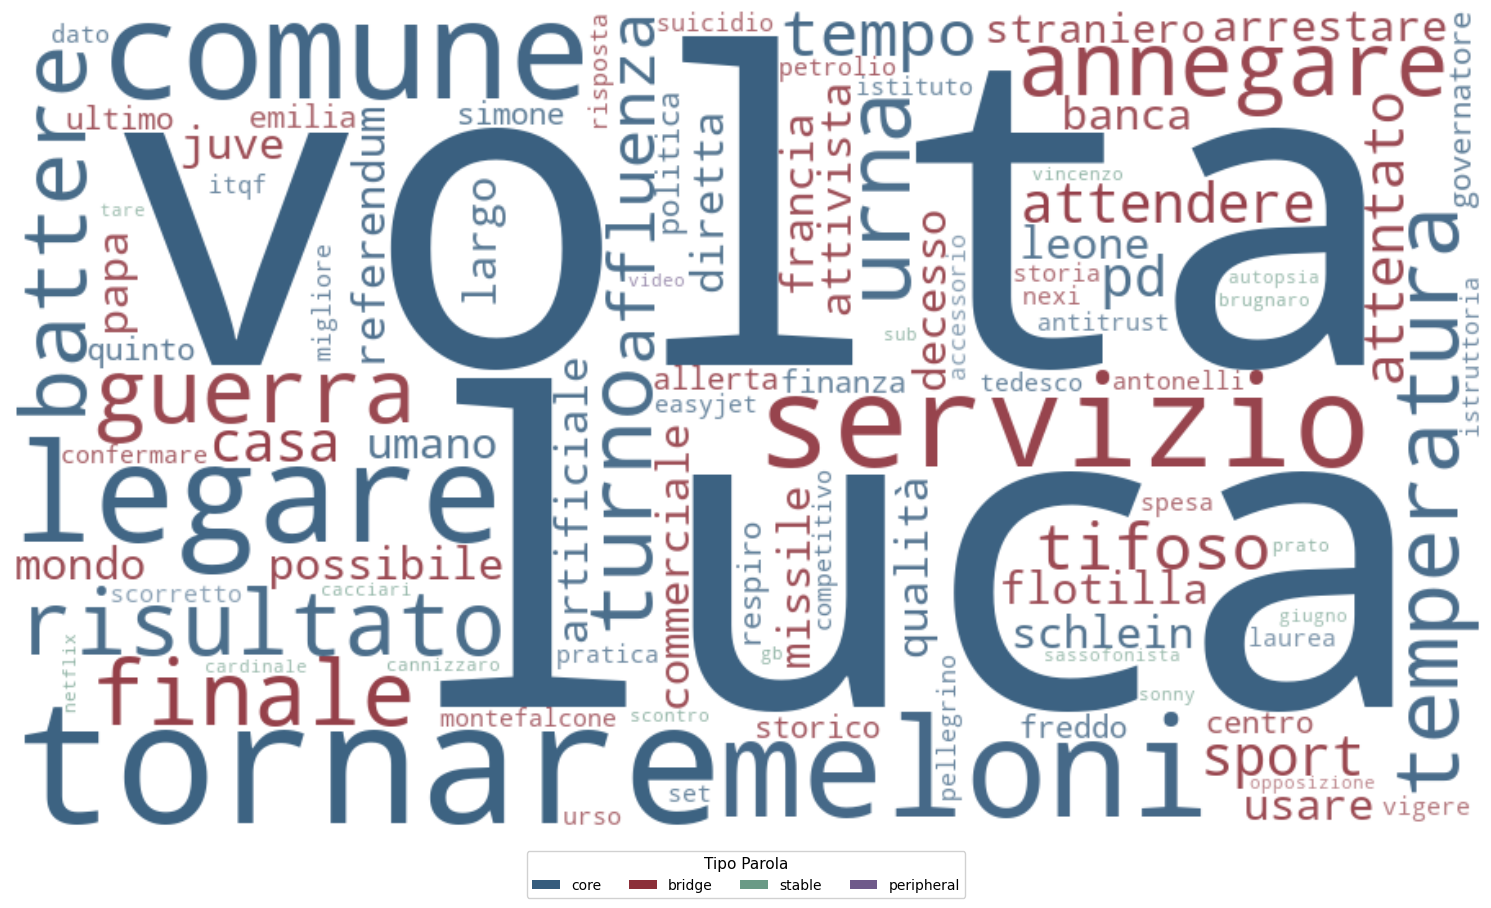

In [43]:
plot_daily_wordcloud(top_nodes)

### 27.2 Daily recap of the last 24 hours

In [44]:
recap_articles = select_articles_for_recap(
    clusters_df=clusters_df,
    data=data,
    lemma_to_forms=lemma_to_forms,
    tags_ranking_df=tags_ranking_df,
    top_n_clusters=10,
    top_k_news_per_cluster=3,
    min_articles=MIN_ARTICLES,
    min_sources=MIN_SOURCES,
)

n_temi = recap_articles['topic_id'].nunique() if not recap_articles.empty else 0
print(f"Articoli selezionati per il riassunto: {len(recap_articles)} "
      f"da {n_temi} temi")

day_recap = summarise_day_recap(
    api_key=MISTRAL_API_KEY,
    recap_articles_df=recap_articles,
    model=MISTRAL_MODEL,
)

display(Markdown(day_recap))

Articoli selezionati per il riassunto: 25 da 10 temi


2026-05-26 11:01:24,020 INFO HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 200 OK"


Nelle ultime 24 ore sono state pubblicate notizie che hanno messo in luce diversi temi di rilievo. In Francia, il caldo record ha causato sette decessi, cinque dei quali per annegamento e due durante attività sportive all’aperto, come riportato da più fonti. Parallelamente, è stato annunciato un evento di portata storica: Papa Leone XIV ha presentato l’enciclica *Magnifica Humanitas*, dedicata alla custodia della persona umana nell’era dell’intelligenza artificiale, sottolineando i rischi di uno sviluppo sregolato di queste tecnologie.

Sul fronte politico italiano, Vincenzo De Luca è stato eletto sindaco di Salerno per la quinta volta, come confermato dagli exit poll. L’ex governatore della Campania ha dichiarato che lavorerà senza sosta per il rilancio della città, dopo una campagna elettorale che lo ha visto vincere senza il sostegno del Pd. Intanto, in Piemonte si sono svolte le elezioni comunali, con i primi risultati che indicano una vittoria del centrosinistra in alcuni centri, mentre il centrodestra ha prevalso in altri.

In ambito sportivo, la squadra di basket di New York è tornata in finale Nba dopo 27 anni, superando Cleveland con un netto 4-0. Nel calcio, la Lega ha ufficializzato le date della prossima Serie A, che inizierà il 23 agosto, con la finale di Coppa Italia fissata per il 19 maggio.

Sul versante della sicurezza, è stato arrestato a Reggio Emilia un 22enne accusato di preparare un attentato per conto dello Stato Islamico, mentre a Tokyo un episodio di intossicazione in un centro commerciale ha riacceso il ricordo degli attentati con il sarin degli anni ’90. Infine, l’Antitrust ha avviato un’istruttoria su EasyJet per pratiche commerciali scorrette legate alla vendita di servizi accessori.

### 27.3 Top 10 articles with highlighted concepts

Selected by `score_news_importance` (concept density normalised by log word count), rendered as a single tall image. Each article header shows the source and the publication date / time. Concept highlight colour reflects the structural role of the concept.

In [45]:
# Render all top 10 articles as a single tall image, with a shared legend
# at the bottom. Date is shown next to the source whenever available.
top10_rows    = [row for _, row in top10_news.iterrows()]
top10_matches = [row['matched_concepts'] for _, row in top10_news.iterrows()]

html = render_news_html(
    news_rows=top10_rows,
    matched_concepts_per_row=top10_matches,
    lemma_to_forms=lemma_to_forms,
    tags_ranking_df=tags_ranking_df
)

display(HTML("""
<style>
.news-kw { text-decoration: underline; text-underline-offset: 2px; font-weight: 600; }
.news-kw.role-core         { color: #355C7D; }
.news-kw.role-bridge       { color: #8C2F39; }
.news-kw.role-stable       { color: #6A9A86; }
.news-kw.role-peripheral   { color: #6F5A8A; }
.news-kw.role-generic      { color: #9E9E9E; }
.news-kw.role-unclassified { color: #555555; }
</style>
"""))

display(HTML(html))

### 27.4 Top-5 core + top-5 bridge concepts - ego-graph analysis

For each concept the radius-1 ego graph is plotted with a concentric-shell layout (rings by edge weight), accompanied by the LLM-generated description anchored on representative articles.


  VOLTA  [core]
Vincenzo De Luca è stato rieletto sindaco di Salerno per la quinta volta, un record che intreccia politica, storia locale e il suo stile controverso, mentre la parola ricorre anche in altri contesti, dalla scienza allo sport.



2026-05-26 11:01:25,265 WARNING Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


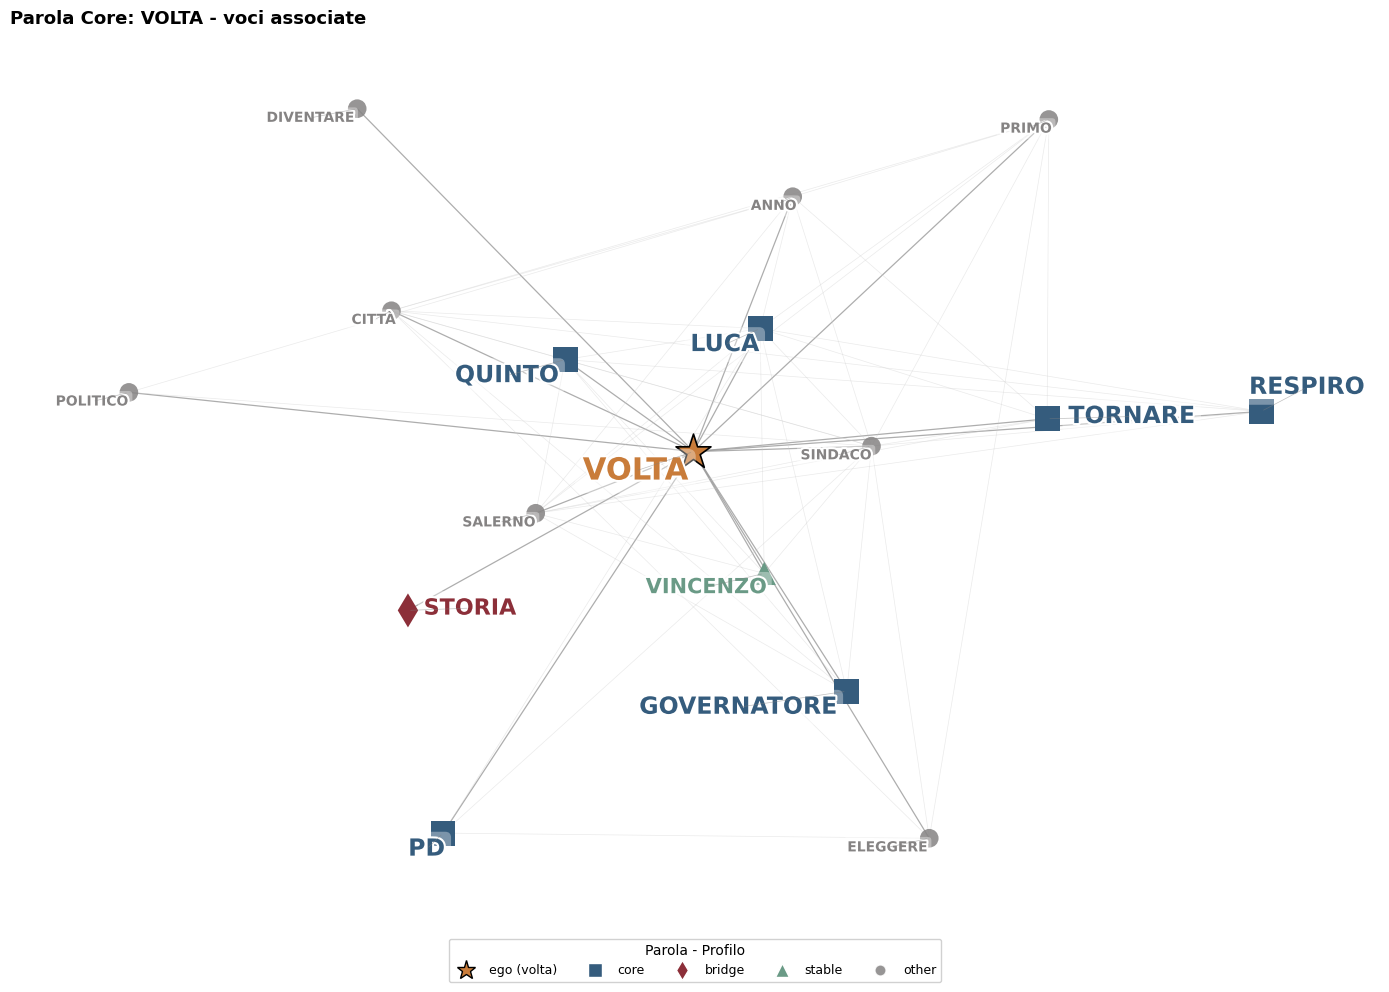


  LUCA  [core]
Vincenzo De Luca è stato rieletto sindaco di Salerno per la quinta volta, mentre il suo nome domina le elezioni comunali tra polemiche politiche, vittorie al primo turno e confronti con centrodestra e Pd.



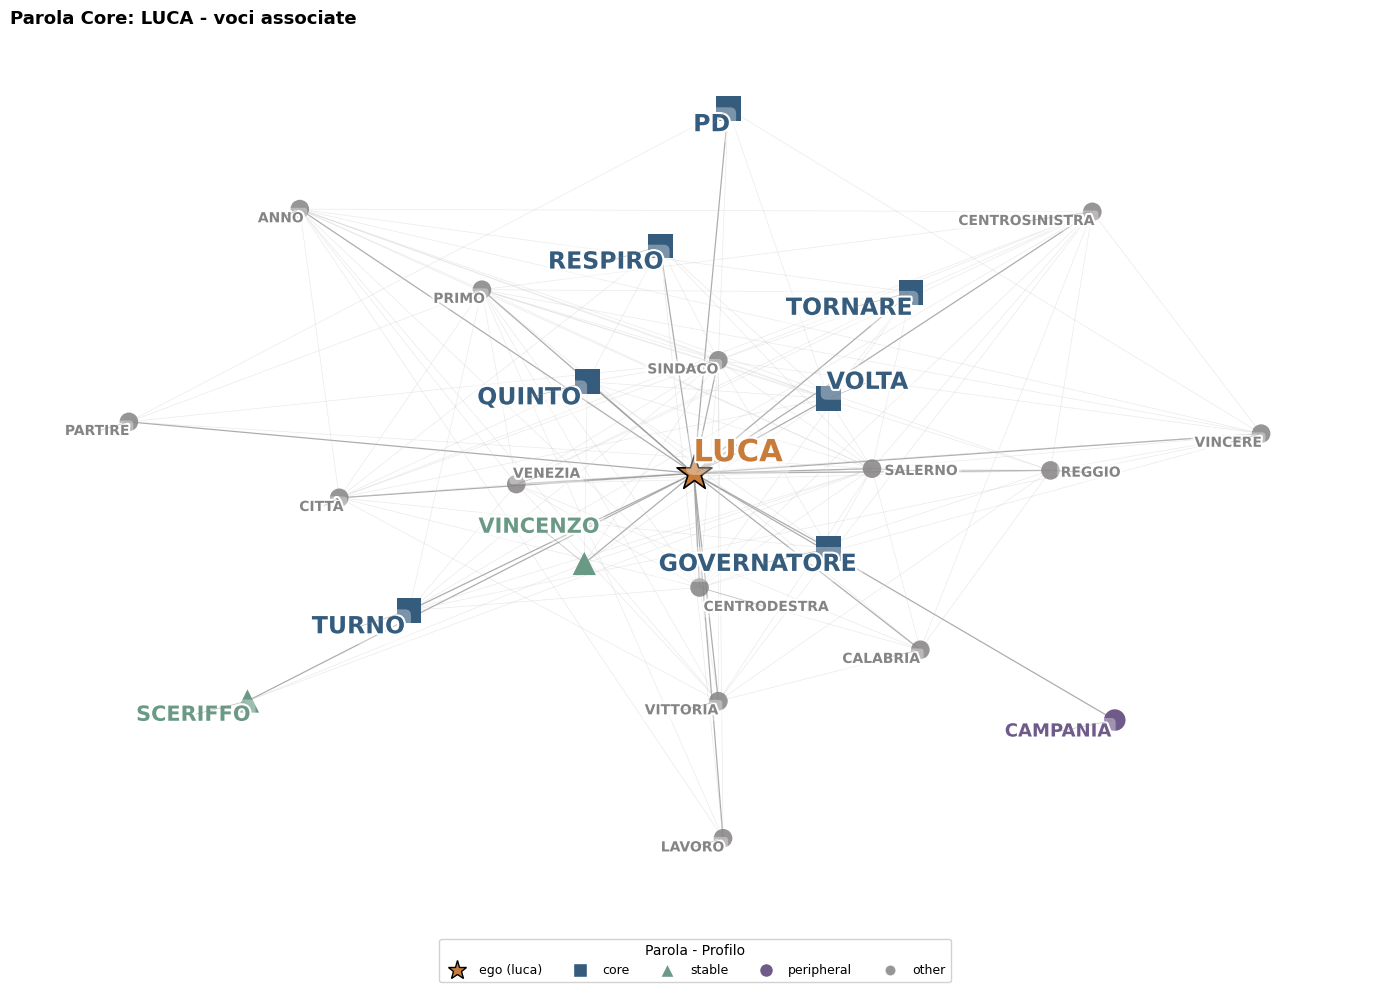


  TORNARE  [core]
Le elezioni comunali fanno tornare al potere vecchi sindaci (Biffoni a Prato) e nuovi equilibri (centrodestra a Venezia, De Luca a Salerno), mentre la parola unisce anche serie tv, ritorni sportivi e riaperture post-pandemia.



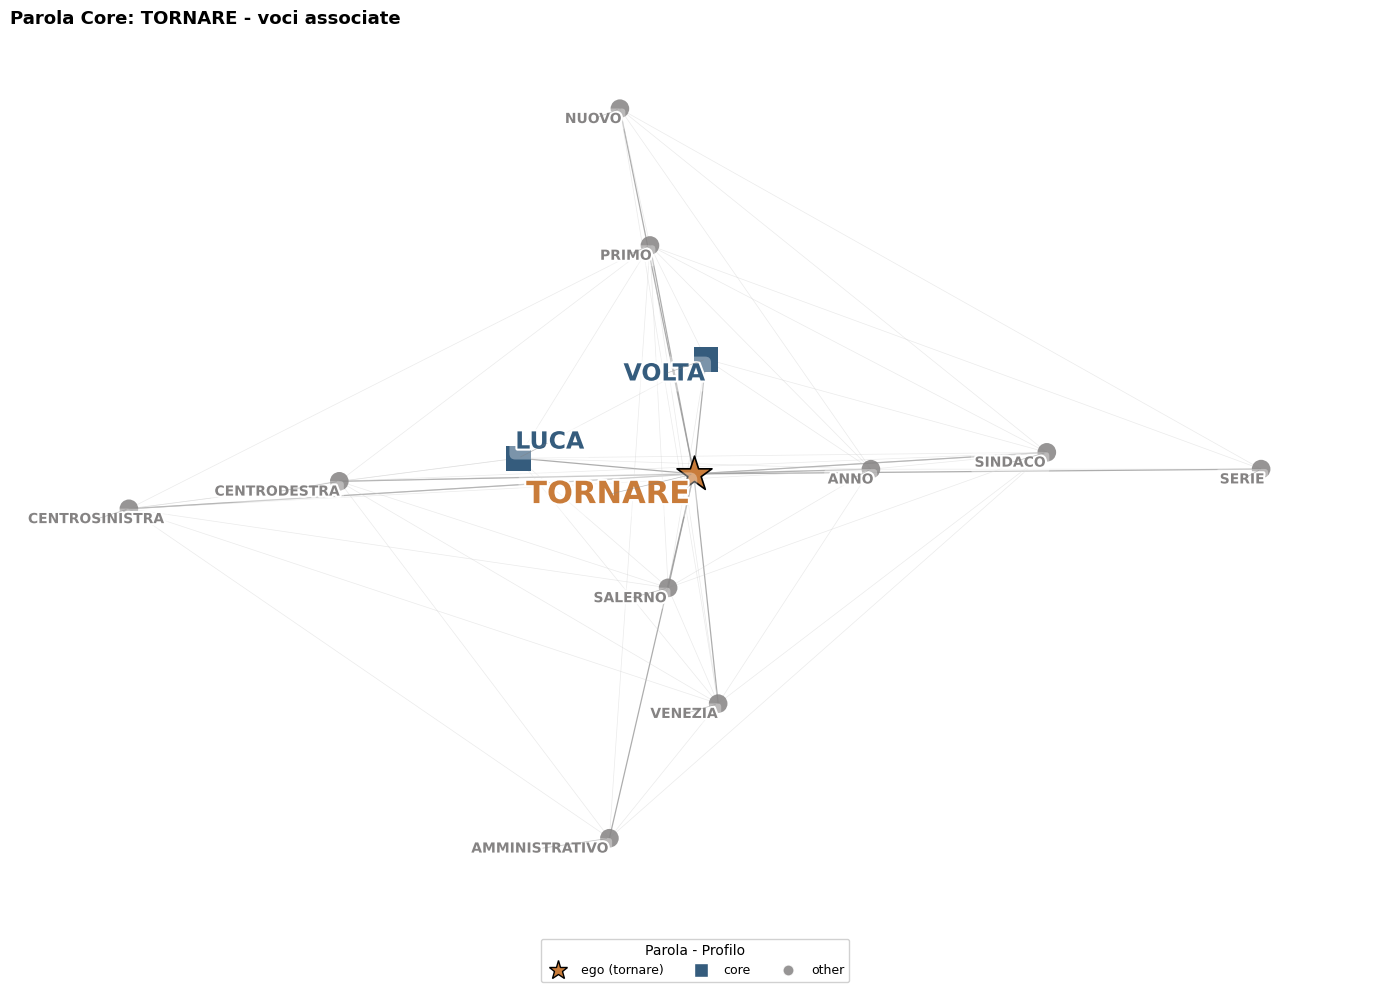


  LEGARE  [core]
Il caldo record in Francia lega decessi e rischi sportivi, mentre la Lega calcio fissa date e finali, e Ferrari svela la sua prima elettrica: una parola che unisce emergenza climatica, sport e innovazione.



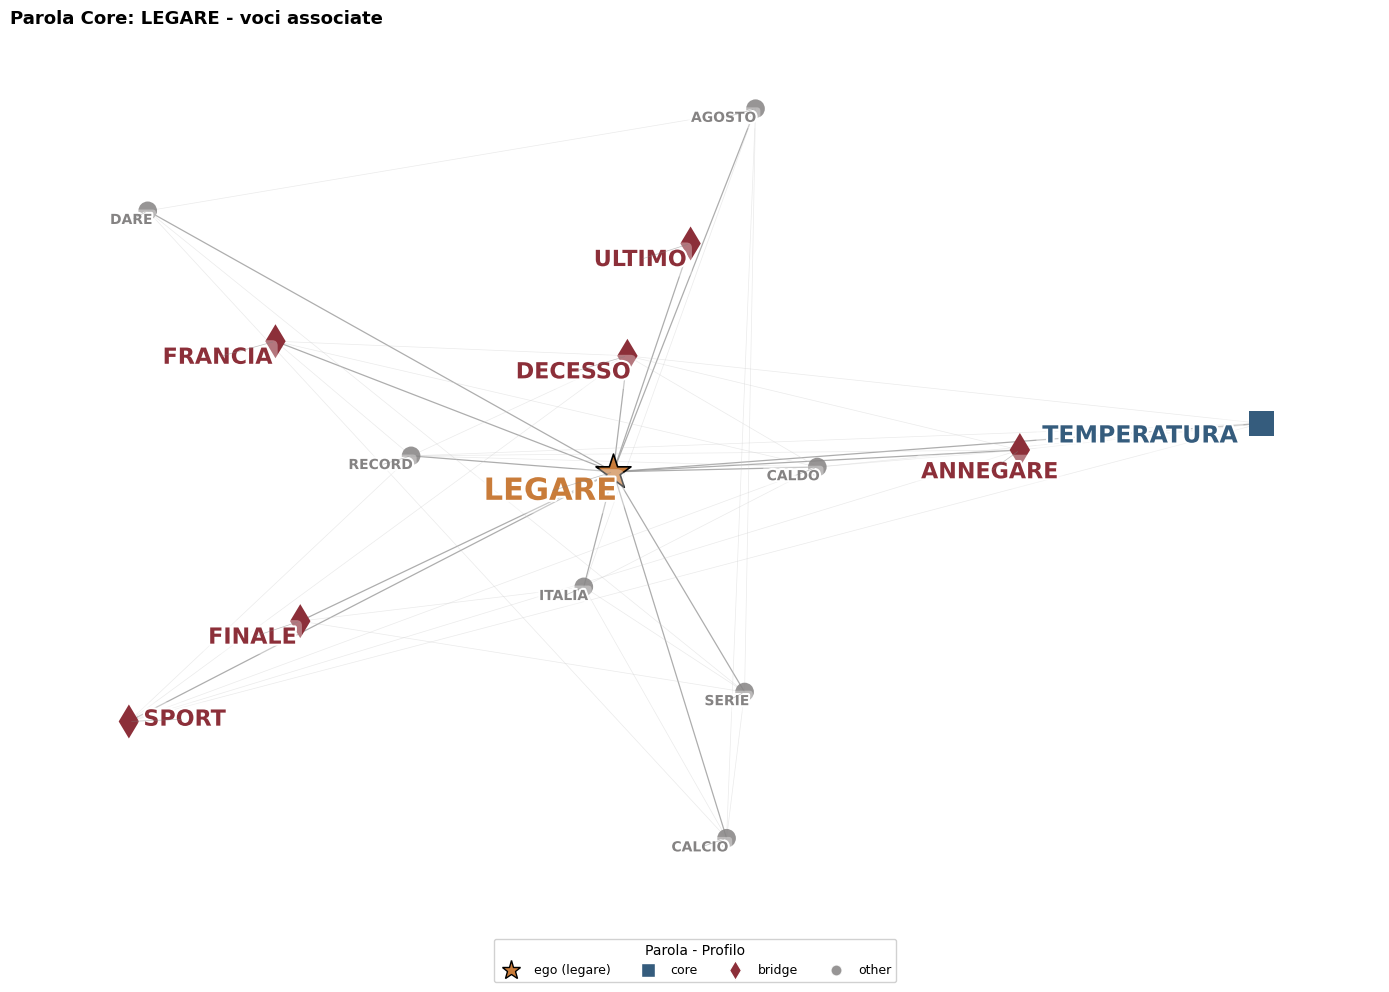


  COMUNE  [core]
Le elezioni comunali in Piemonte e Calabria hanno ribaltato equilibri politici: il centrodestra strappa Reggio al centrosinistra, mentre a Moncalieri e Venaria si giocano riconferme e ballottaggi.



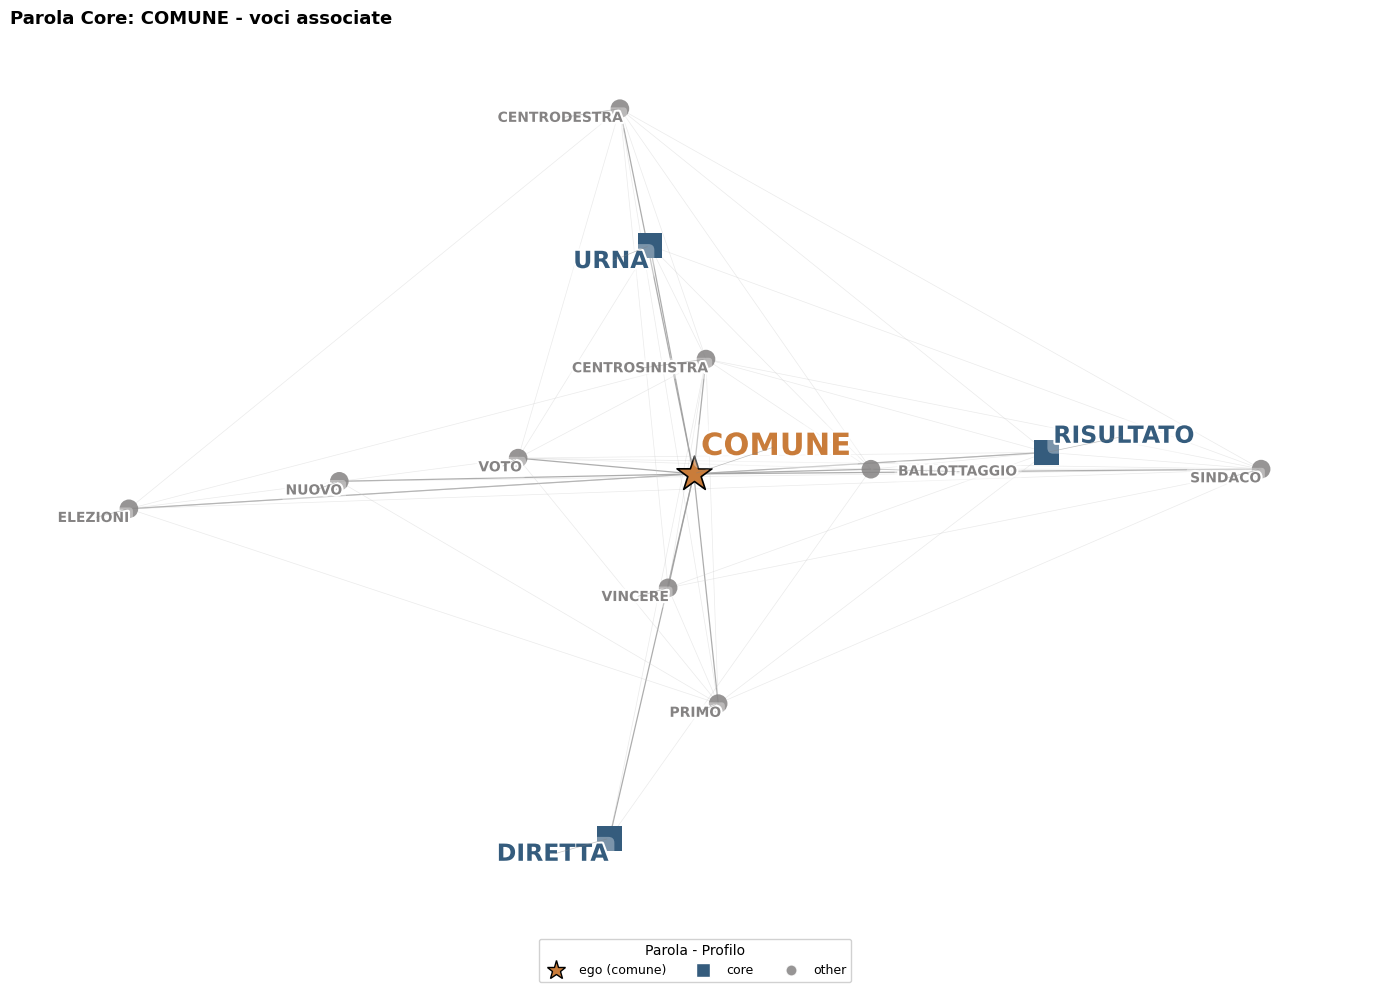


  SERVIZIO  [bridge]
L’Antitrust indaga EasyJet per servizi accessori obbligati di default, mentre la parola lega anche sostegno psicologico agli studenti e iniziative locali di maggio.



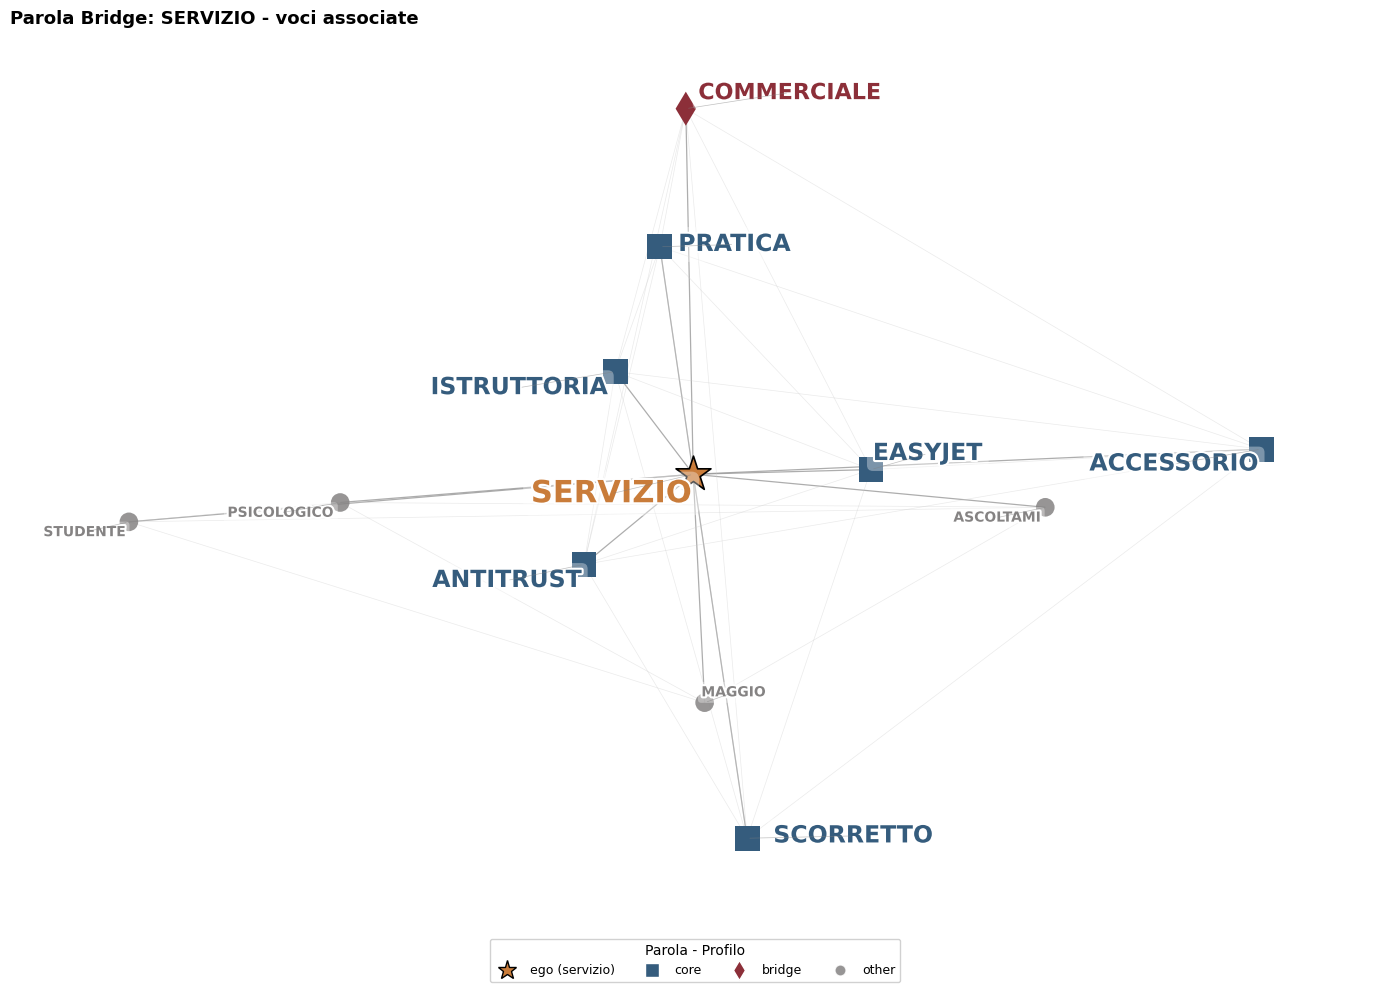


  ANNEGARE  [bridge]
Il caldo record in Francia ha causato annegamenti (cinque morti in acqua) e incidenti sportivi, mentre in Sicilia due tonni sono morti in un torrente: la parola unisce emergenza climatica e tragedie impreviste.



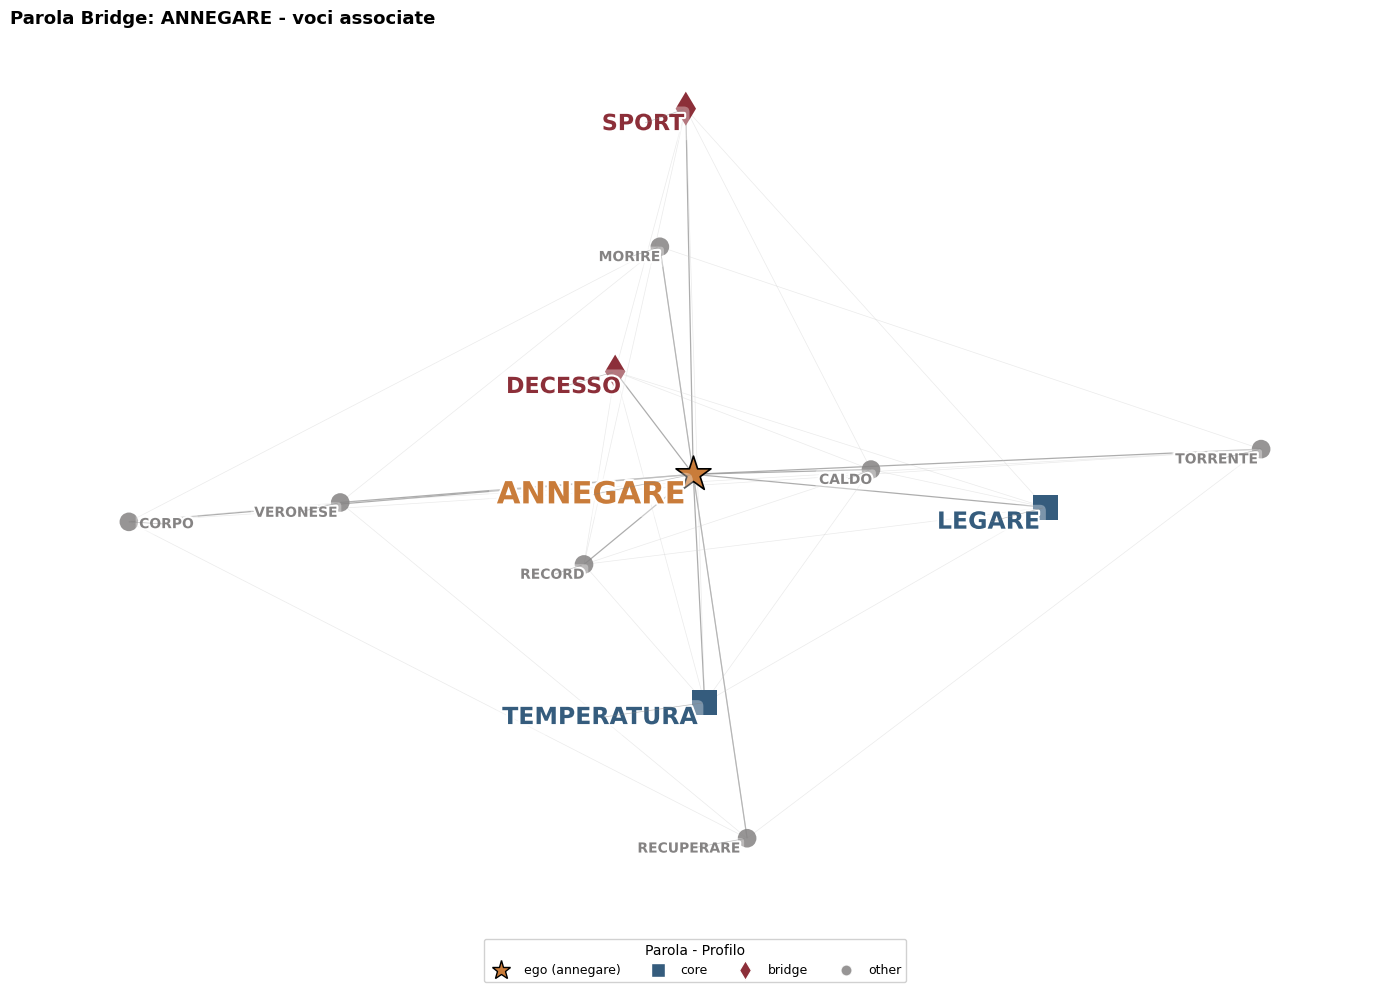


  GUERRA  [bridge]
Trump definisce "autodifesa" gli attacchi in Iran mentre si negozia un accordo per chiudere anni di tensioni, tra aperture diplomatiche e minacce di escalation.



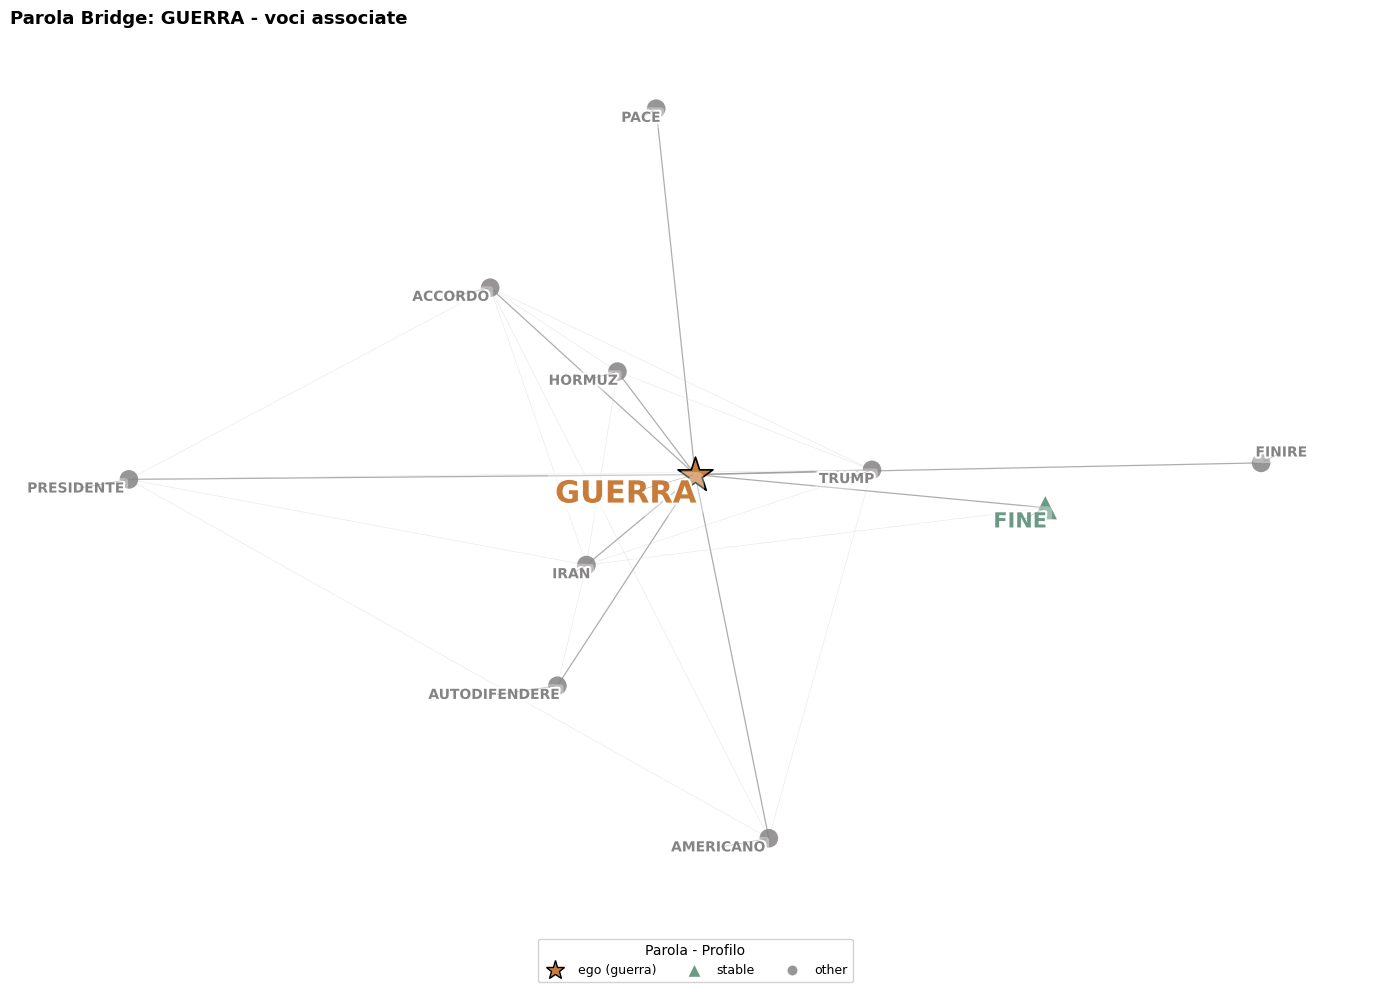


  FINALE  [bridge]
Finale unisce sport e cultura: l’Inter sfiora il trionfo, i Knicks tornano in NBA dopo 27 anni, e al cinema arriva l’ultimo atto di Bowie con materiali inediti.



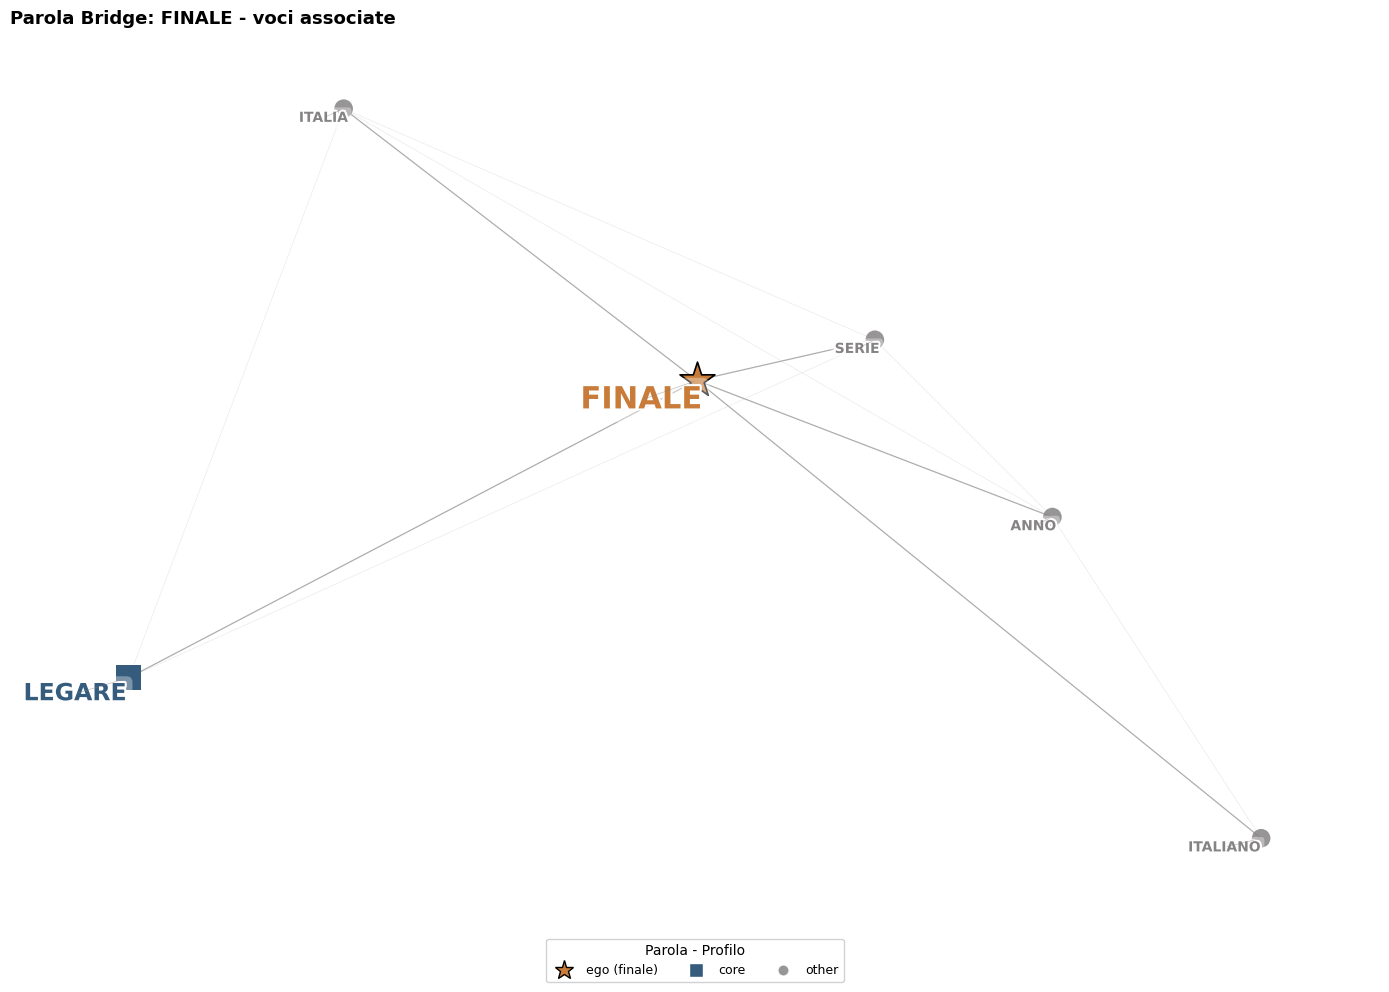


  TIFOSO  [bridge]
Un tifoso juventino è stato ferito prima del derby di Torino, scatenando scontri tra ultrà e ritardi in campo, mentre le notizie collegano violenza, ospedali e polemiche sul calcio.



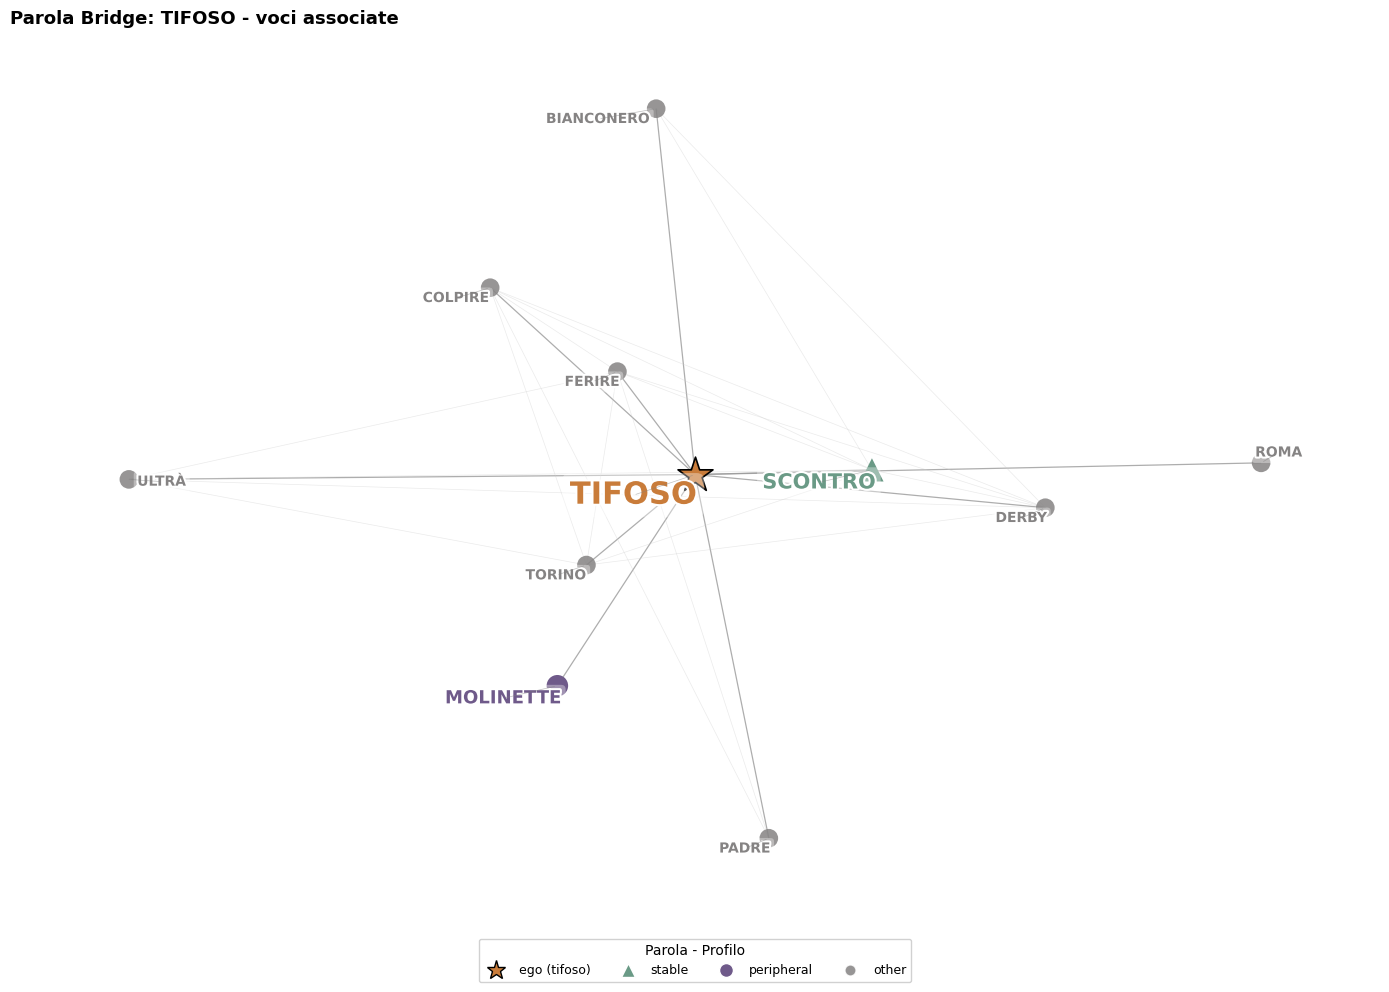

In [46]:
for tag, content in results.items():
    print(f"\n{'='*60}")
    print(f"  {tag.upper()}  [{content['role']}]")
    print(f"{'='*60}")

    print(content['description'])
    print()

    # The visualization is useful, even though it is currently not used beyond the plot
    if tag in top5_core:
        plot_ego_graph(concepts_graph, tag, tags_ranking_df, ego_type='core')
    else:
        plot_ego_graph(concepts_graph, tag, tags_ranking_df, ego_type='bridge')

### 27.5 Main themes through community detection

Each Louvain community is rendered as a single image of its most representative articles, with key concepts highlighted inline. The image both visualises the theme and shows the supporting evidence, so a separate textual listing of the articles is no longer produced.

In [47]:
# For each main theme: print the LLM-generated title as a section header,
# then render the selected representative news as a single tall image with
# highlighted concepts. The image acts simultaneously as theme visualisation
# and as the list of representative articles, so the separate textual
# listing produced previously by format_selected_news is no longer needed.
for comm_idx, content in community_results.items():
    print(f"\n{'='*60}")
    print(f"  TEMA PORTANTE {comm_idx} - {content['title'].upper().replace('*','')}")
    print(f"{'='*60}")

    top_news = content['top_news']
    if top_news.empty:
        print('   (nessuna notizia rappresentativa)')
        continue

    # Use the matched_concepts already computed by score_news_for_community
    # (canonical lemmas of community nodes found in each article).
    rows    = [row for _, row in top_news.iterrows()]
    matches = [row['matched_concepts'] for _, row in top_news.iterrows()]

    html = render_news_html(
        news_rows=rows,
        matched_concepts_per_row=matches,
        lemma_to_forms=lemma_to_forms,
        tags_ranking_df=tags_ranking_df
    )

    display(HTML(html))


  TEMA PORTANTE 28 - CENTROSINISTRA IN DIFFICOLTÀ DOPO LE COMUNALI



  TEMA PORTANTE 20 - DE LUCA SINDACO DI SALERNO PER LA QUINTA VOLTA



  TEMA PORTANTE 19 - PAPA LEONE XIV E L’INTELLIGENZA ARTIFICIALE



  TEMA PORTANTE 33 - EASYJET SOTTO ACCUSA PER I BAGAGLI ONLINE



  TEMA PORTANTE 18 - ELECTROLUX E I TAGLI SOTTO ESAME


### 27.6 Cross-source coverage and lexical framing - top 5 clusters

For each of the top-5 eligible clusters: LLM-generated title and factual description, coverage barplot across sources, and distinctive TF-IDF terms per source revealing how each outlet frames the same story.

2026-05-26 11:01:39,838 INFO HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 200 OK"


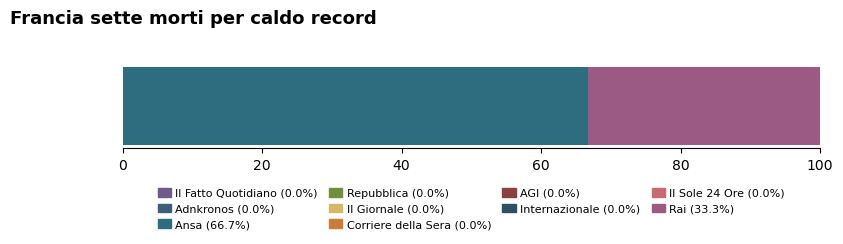

In Francia sette decessi sono stati collegati alle temperature record, cinque per annegamento e due durante attività sportive. Il caldo persisterà fino a sabato.
Termini distintivi per testata giornalistica:
ANSA: temperature, calde, resteranno, sabato, alte
RAI: valori, sinner, persone, riscontrati, facevano




2026-05-26 11:01:41,956 INFO HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 200 OK"


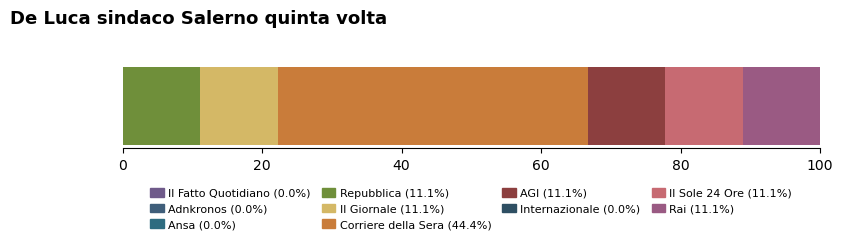

Vincenzo De Luca è stato eletto sindaco di Salerno per la quinta volta, vincendo al primo turno con oltre il 57%. Torna alla guida della città dopo dieci anni.
Termini distintivi per testata giornalistica:
AGI: conquista, politici, nascono, leader, nazionale
CORRIERE DELLA SERA: politico, ultimo, sindaco, figlio, anni
IL GIORNALE: candidato, campana, quarta, governatore, città
IL SOLE 24 ORE: successo, carica, ricoprire, poll, exit
RAI: eletto, crollo, trainato, tradizionali, civiche
REPUBBLICA: plebiscitato, linea, esponente, decimale, comunali




2026-05-26 11:01:43,722 INFO HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


   Rate limit, waiting 10s (retry 1/5)...


2026-05-26 11:01:55,519 INFO HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 200 OK"


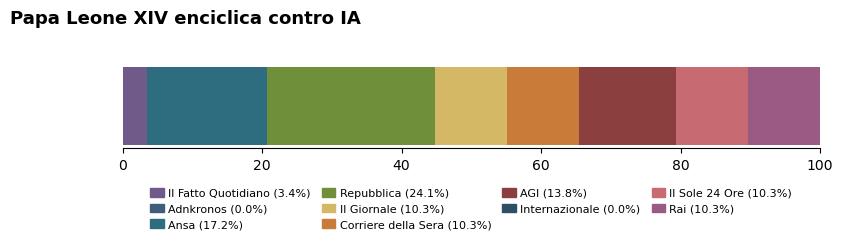

Papa Leone XIV pubblica l’enciclica *Magnifica Humanitas* per criticare i rischi dell’intelligenza artificiale e promuovere l’umanità. Coinvolti esperti tech e istituzioni.
Termini distintivi per testata giornalistica:
AGI: chiesa, agostino, umanità, cattedrale, sociale
ANSA: magnifica, disarmare, enciclica, rimaniamo, presidente
CORRIERE DELLA SERA: testo, magnifica, industriale, enciclica, anticipo
IL FATTO QUOTIDIANO: quotidiano, fatto, proviene, edicola, vignetta
IL GIORNALE: tema, demografia, inselvini, famiglia, corsi
IL SOLE 24 ORE: ultimi, sanità, mythos, favorire, mld
RAI: pericoloso, sovranità, canadese, mondiali, caffo
REPUBBLICA: tech, silicon, pontefice, cofondatore, critica




2026-05-26 11:01:58,133 INFO HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


   Rate limit, waiting 10s (retry 1/5)...


2026-05-26 11:02:09,609 INFO HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 200 OK"


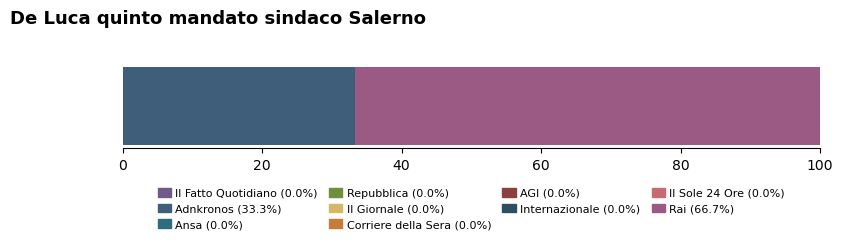

Vincenzo De Luca è stato eletto sindaco di Salerno per la quinta volta. Ha annunciato che lavorerà senza sosta per realizzare il programma di rilancio della città.
Termini distintivi per testata giornalistica:
ADNKRONOS: voto, riempie, orgoglio, governatore, assicura
RAI: volta, respiro, quinta, sindaco, dice




2026-05-26 11:02:10,517 INFO HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


   Rate limit, waiting 10s (retry 1/5)...


2026-05-26 11:02:22,669 INFO HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 200 OK"


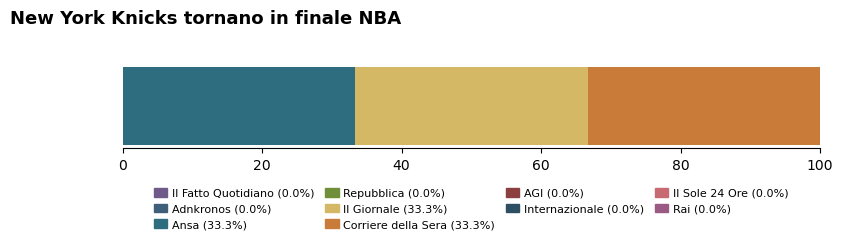

I New York Knicks raggiungono la finale NBA dopo 27 anni, battendo Cleveland 4-0. La squadra guidata da Brunson si prepara per la sfida decisiva.
Termini distintivi per testata giornalistica:
ANSA: cavaliers, sconfitti, torna, anni, finale
CORRIERE DELLA SERA: finale, anni, staff, segnano, volta
IL GIORNALE: storia, corre, difende, guida, occasione




In [48]:
cluster_summaries = {}
framing_by_cluster = {}

for _, row in top5_clusters.iterrows():
    topic_id = row['topic_id']
    cluster_articles = data[data['Topic'] == topic_id]
    concepts = row['concepts']

    # Title and description via LLM
    summary = summarise_cluster(
        MISTRAL_API_KEY, topic_id, cluster_articles, concepts
    )
    cluster_summaries[topic_id] = summary

    # Coverage asymmetry (visual)
    describe_cat_column_stacked(
        top_data[top_data['Topic'] == topic_id],
        'source',
        journal_color_map,
        custom_title=summary['title']
    )

    print(summary['description'])

    # Lexical framing (textual, by source)
    framing_df = extract_framing_per_cluster(cluster_articles, entities_set)
    framing_by_cluster[topic_id] = framing_df

    if framing_df.empty:
        print('Framing: (insufficient sources for contrastive analysis)')
    else:
        print('Termini distintivi per testata giornalistica:')
        display_framing_table(framing_df)
    print('\n')